![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 4. Process Design Kit (PDK) and Layout

In [101]:
import gdsfactory as gf

## 1. Technology

We will work with the **demo UPVfab PDK**. (There are some other open-source PDKs, in other technologies, feel free to search if interested)

In [102]:
from upvfab.sin300.cband import PDK, cells

Let's view the layer distribution of this PDK. In our case, for the passive devices we will only use the **Layer 1**. 

2026-06-12 14:01:42.770 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


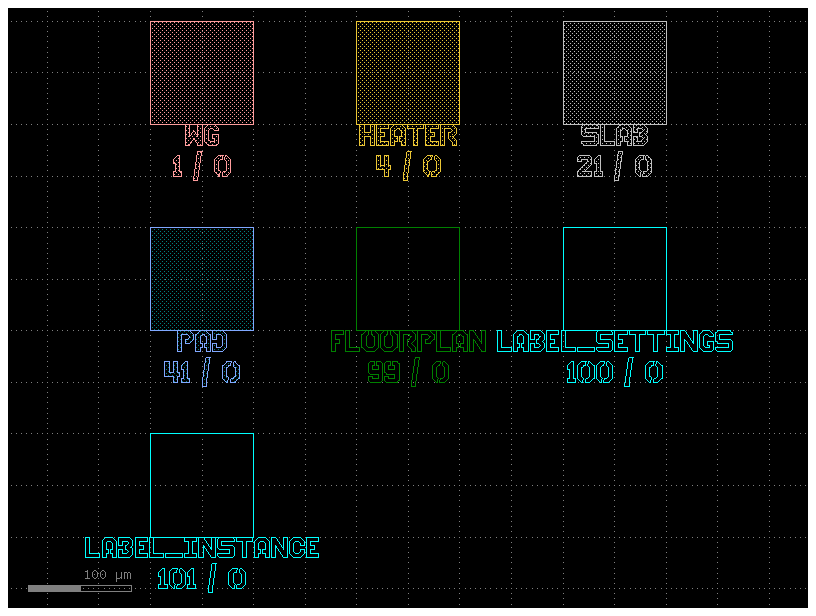

In [103]:
LAYER_VIEWS = PDK.layer_views
c = LAYER_VIEWS.preview_layerset()
c.show()
c.plot()


The new versions of GDS Factory allow to view the Layer Stack also (3D view of the fabrication flow). The following code allows to generate and view the Layer Stack of the generic PDK. Reference: https://www.degruyter.com/document/doi/10.1515/nanoph-2013-0034/html

The layers and the thicknesses have been defined previously on the PDK, so it is possible to view in 3D some of the components in the PDK. 

See the [Reference Manual](https://gdsfactory.github.io/gdsfactory/components.html) and read the list of the available components.

Here are some examples of the 3D views of this photonic components

2026-06-12 14:01:43.077 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


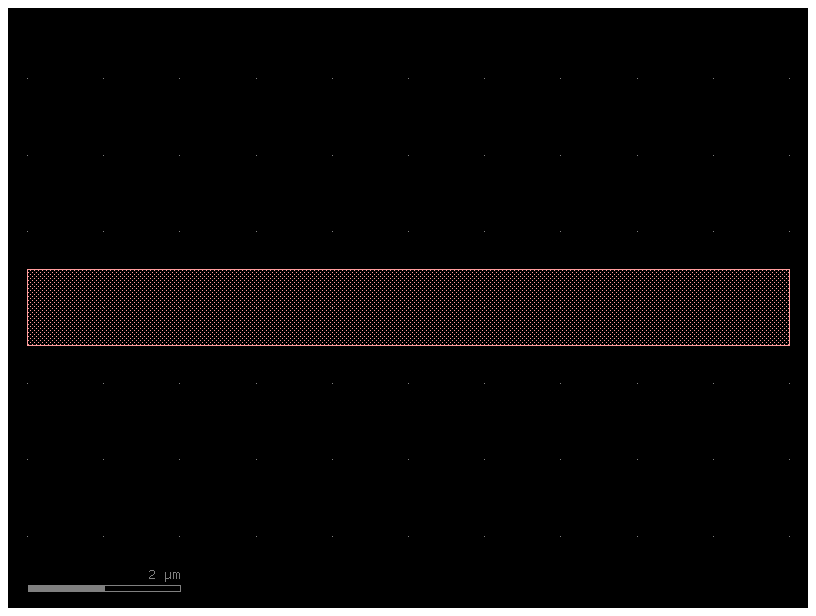

In [104]:
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

c = gf.components.straight(length=10, cross_section=xs)  #Deep 
c.plot() # To view the component on Notebook
c.show() # To view on KLayout
scene = c.to_3d()


2026-06-12 14:01:43.364 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-12 14:01:43.428 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


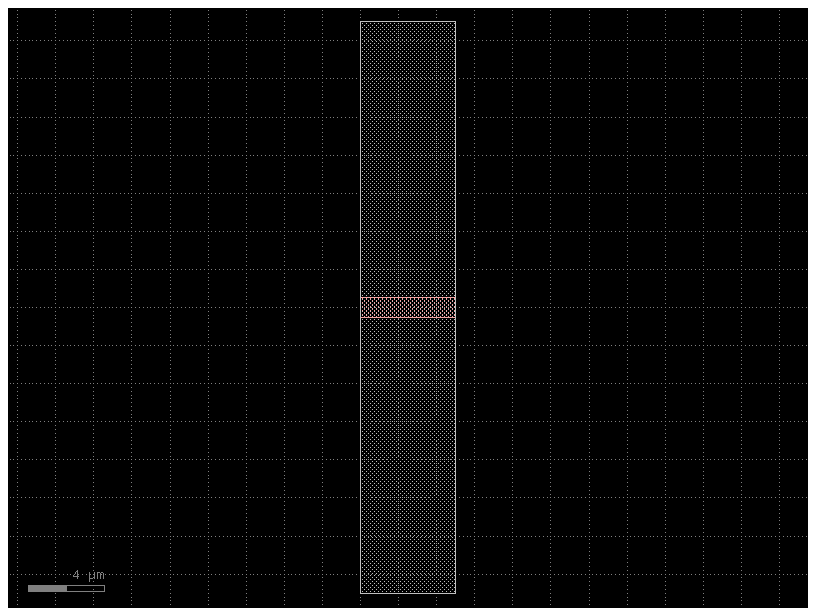

In [105]:
c = gf.components.straight(length=5, cross_section='rib') #Shallow
c.plot()
c.show()

scene = c.to_3d()
c.show()
scene.show()

In [106]:
c = cells.taper_strip_to_ridge(length=10) #Taper
c.show()

scene = c.to_3d()
scene.show()

2026-06-12 14:01:43.710 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


2026-06-12 14:01:43.947 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


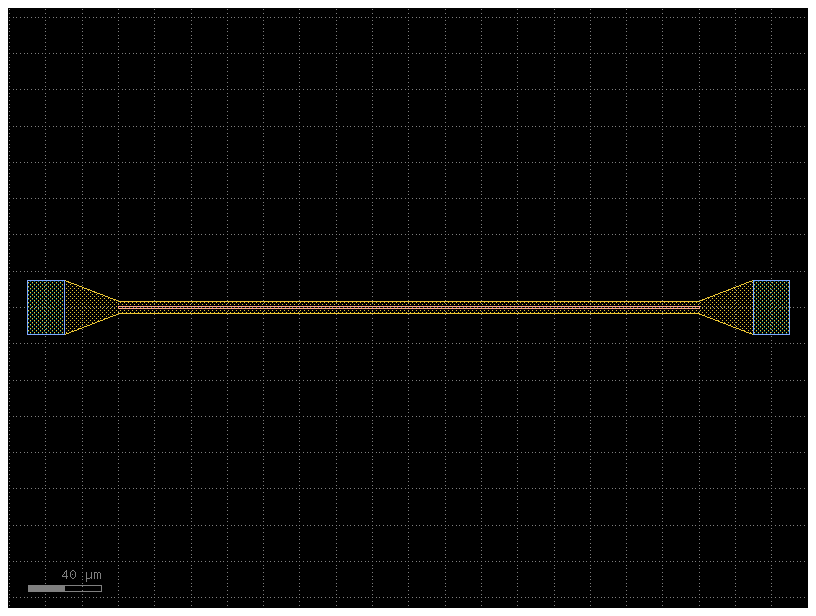

In [107]:
c = cells.straight_heater_metal()

#c.pprint_ports()

c.plot()
c.show()
#c.draw_ports()

scene = c.to_3d()
scene.show()

- Use your design results from Lab2 and Lab3 to create **layout** instances of your designed components: DCs, MMIs, MZIs & Ring Resonators. 

Acoplador

Medidas acoplador: core width = (1.2, 1.2)
Slab thickness = 0
Core thickness = 300 nm
gap = 600 nm

Acoplador utilizado para observar la función de transferencia K vs L/Lpi

2026-06-12 14:01:44.255 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


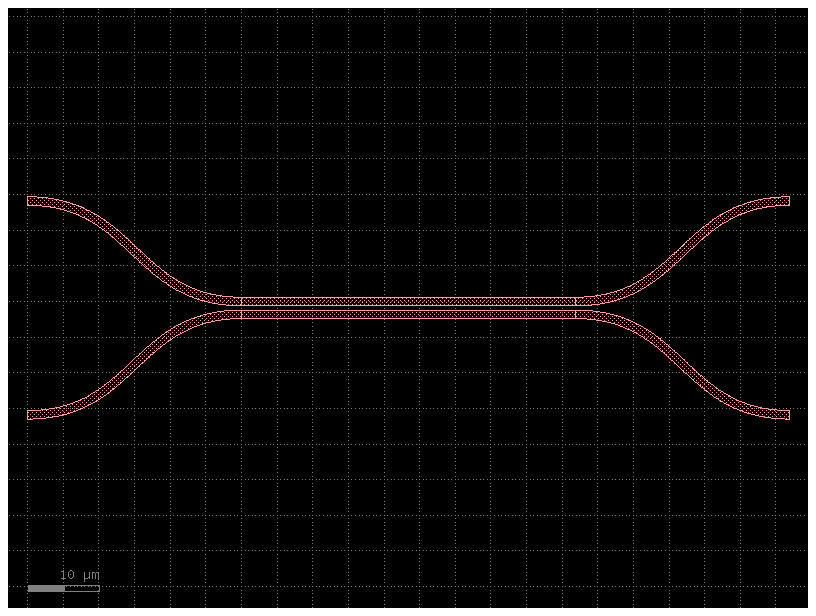

In [ ]:
gf.clear_cache()
acoplador = gf.Component("Acoplador simple")
# =======================================================================
# MODIFICACIÓN 1: Usamos la función constructora correcta de gdsfactory
# Extraemos la capa tecnológica base de una guía por defecto
capa_base = gf.components.straight().ports["o1"].layer
# SOLUCIÓN: Cambiamos gf.CrossSection por gf.cross_section.cross_section
seccion_300nm = gf.cross_section.cross_section(width=1.2, layer=capa_base)
# =======================================================================
# 2. Creamos la pieza "molde" de la recta usando la nueva sección
guia_recta = gf.components.straight(length=93.83767536699492/2, cross_section=seccion_300nm) 
# 3. Añadimos la recta inferior (se queda en el origen)
recta_inferior = acoplador.add_ref(guia_recta)
# 4. Añadimos la recta superior como una NUEVA referencia
recta_superior = acoplador.add_ref(guia_recta)
# 5. Movemos la referencia manteniendo el gap de 600nm (0.6 um)
separacion_centros = 0.6 + 1.2 
recta_superior.movey(-separacion_centros)
# ==========================================
# CÓDIGO AÑADIDO PARA COMPLETAR EL ACOPLADOR
# ==========================================
# 1. Definimos los brazos de acceso
distancia_separacion_y = 30
longitud_transicion = 30 
# Calculamos el desplazamiento vertical (offset) que debe hacer cada curva
offset_y = (distancia_separacion_y - separacion_centros) / 2
# Pasamos la misma 'seccion_300nm' a la curva en S
s_bend = gf.components.bend_s(size=(longitud_transicion, offset_y), cross_section=seccion_300nm)
# 2. Añadir y conectar los accesos del LADO IZQUIERDO (Entradas)
s_in_top = acoplador.add_ref(s_bend)
s_in_top.connect("o2", recta_superior.ports["o1"]) 
s_in_bot = acoplador.add_ref(s_bend)
s_in_bot.mirror_y()
s_in_bot.connect("o2", recta_inferior.ports["o1"])
# 3. Añadir y conectar los accesos del LADO DERECHO (Salidas)
s_out_top = acoplador.add_ref(s_bend)
s_out_top.mirror_x() 
s_out_top.connect("o2", recta_superior.ports["o2"])
s_out_bot = acoplador.add_ref(s_bend)
s_out_bot.mirror_y() 
s_out_bot.mirror_x() 
s_out_bot.connect("o2", recta_inferior.ports["o2"])
# 4. DEFINICIÓN DE LOS PUERTOS GLOBALES DEL CIRCUITO
acoplador.add_port("in_top", port=s_in_top.ports["o1"])
acoplador.add_port("in_bot", port=s_in_bot.ports["o1"])
acoplador.add_port("out_top", port=s_out_top.ports["o1"])
acoplador.add_port("out_bot", port=s_out_bot.ports["o1"])
# ==========================================
# VISUALIZACIÓN
# ==========================================
acoplador.plot() 
acoplador.show() 
scene = acoplador.to_3d()
scene.show()

Multimode interferometer

2026-06-12 14:01:44.594 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


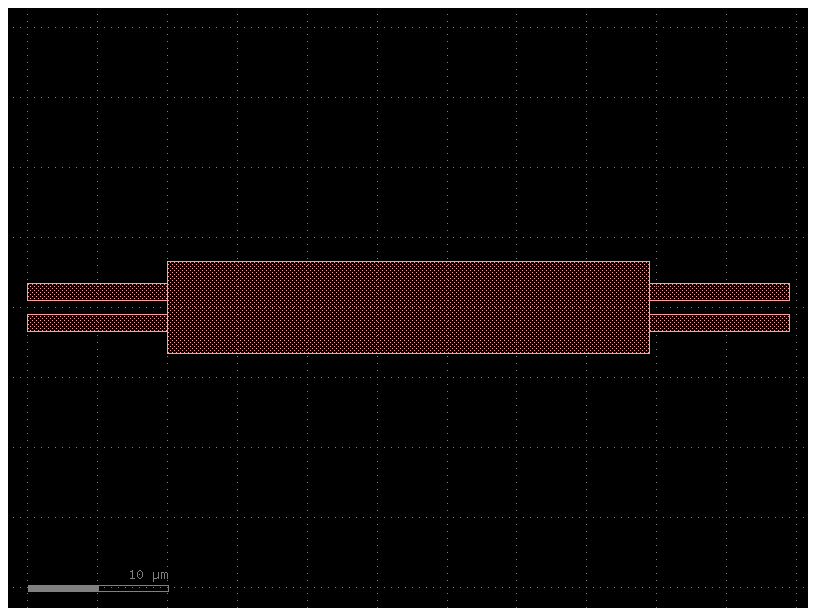

In [ ]:
gf.clear_cache()
mmi2x2 = gf.Component("MMI_2x2_Limpio")
# =======================================================================
# 1. CAPAS Y SECCIONES TRANSVERSALES
# Extraemos la capa tecnológica base del PDK
capa_base = gf.components.straight().ports["o1"].layer
# Guías de acceso (ancho estándar de 1.2 um)
seccion_acceso = gf.cross_section.cross_section(width=1.2, layer=capa_base)
# Cuerpo (body) del MMI (ancho solicitado de 6.6 um)
ancho_body = 6.6
seccion_body = gf.cross_section.cross_section(width=ancho_body, layer=capa_base)
# =======================================================================
# 2. CUERPO (BODY) DEL MMI
# Longitud para interferencia pareada (paired interference) en un divisor 3dB (L = L_pi / 2)
L_pi = 69.03598607255596
longitud_mmi = L_pi / 2 
cuerpo = gf.components.straight(length=longitud_mmi, cross_section=seccion_body)
body_ref = mmi2x2.add_ref(cuerpo)
# 3. GUÍAS DE ACCESO RECTAS (ENTRADAS Y SALIDAS)
# Posiciones a 1/6 y -1/6 del ancho del body (6.6 / 6 = 1.1 um)
posicion_y = ancho_body / 6.0  
longitud_acceso = 10.0  # Longitud de los "rabillos" de entrada/salida
guia_recta = gf.components.straight(length=longitud_acceso, cross_section=seccion_acceso)
# --- LADO IZQUIERDO (Entradas en X = 0) ---
in_top = mmi2x2.add_ref(guia_recta)
in_top.movex(-longitud_acceso)
in_top.movey(posicion_y)
in_bot = mmi2x2.add_ref(guia_recta)
in_bot.movex(-longitud_acceso)
in_bot.movey(-posicion_y)
# --- LADO DERECHO (Salidas en X = longitud_mmi) ---
out_top = mmi2x2.add_ref(guia_recta)
out_top.movex(longitud_mmi)
out_top.movey(posicion_y)
out_bot = mmi2x2.add_ref(guia_recta)
out_bot.movex(longitud_mmi)
out_bot.movey(-posicion_y)
# =======================================================================
# 4. DEFINICIÓN DE LOS PUERTOS GLOBALES DEL CIRCUITO
# =======================================================================
# Los puertos exteriores quedan apuntando hacia fuera listos para conectar
mmi2x2.add_port("in_top", port=in_top.ports["o1"])
mmi2x2.add_port("in_bot", port=in_bot.ports["o1"])
mmi2x2.add_port("out_top", port=out_top.ports["o2"])
mmi2x2.add_port("out_bot", port=out_bot.ports["o2"])
# ==========================================
# VISUALIZACIÓN
# ==========================================
mmi2x2.plot() 
mmi2x2.show() 
scene = mmi2x2.to_3d()
scene.show()

MZI no eqilibrado

2026-06-12 14:01:44.953 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


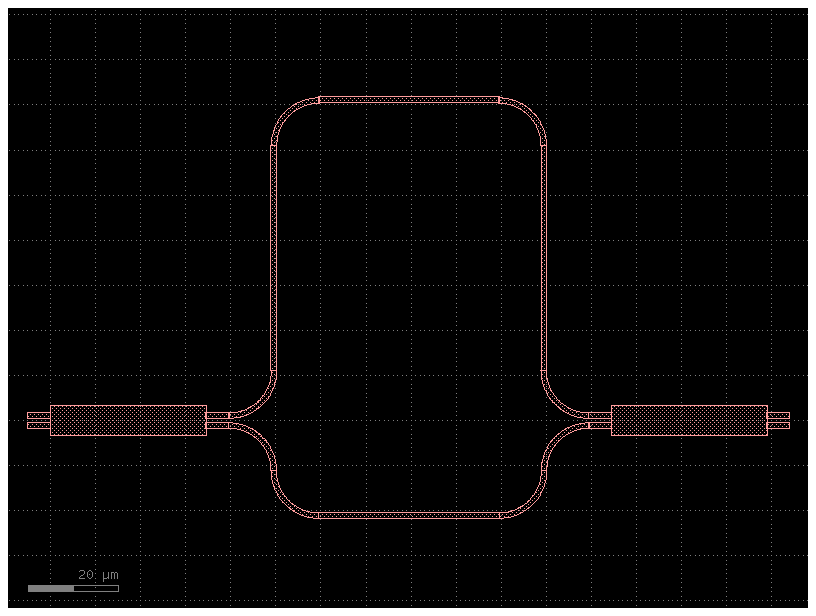

In [110]:
gf.clear_cache()

# =======================================================================
# 1. CELDA DEL MMI 2x2 (Bloque base limpio)
# =======================================================================
@gf.cell
def mmi_2x2_base() -> gf.Component:
    mmi = gf.Component("mmi_2x2_base")
    capa = gf.components.straight().ports["o1"].layer
    sec_acceso = gf.cross_section.cross_section(width=1.2, layer=capa)
    sec_body = gf.cross_section.cross_section(width=6.6, layer=capa)
    
    # Cuerpo del MMI
    longitud_mmi = 69.03598607255596 / 2 
    body = mmi.add_ref(gf.components.straight(length=longitud_mmi, cross_section=sec_body))
    
    # Accesos rectos (1/6 y -1/6)
    pos_y = 6.6 / 6.0  
    l_acc = 5.0
    guia_r = gf.components.straight(length=l_acc, cross_section=sec_acceso)
    
    it = mmi.add_ref(guia_r).movex(-l_acc).movey(pos_y)
    ib = mmi.add_ref(guia_r).movex(-l_acc).movey(-pos_y)
    ot = mmi.add_ref(guia_r).movex(longitud_mmi).movey(pos_y)
    ob = mmi.add_ref(guia_r).movex(longitud_mmi).movey(-pos_y)
    
    mmi.add_port("in_top", port=it.ports["o1"])
    mmi.add_port("in_bot", port=ib.ports["o1"])
    mmi.add_port("out_top", port=ot.ports["o2"])
    mmi.add_port("out_bot", port=ob.ports["o2"])
    return mmi

# =======================================================================
# 2. CONSTRUCCIÓN DEL MZI (Topografía image_e153d4)
# =======================================================================
mzi = gf.Component("MZI_DeltaL_100")

capa_base = gf.components.straight().ports["o1"].layer
width_wg = 1.2
seccion_acceso = gf.cross_section.cross_section(width=width_wg, layer=capa_base)
layer_heater = "HEATER"

# Instanciamos Splitter y Combiner usando nuestro bloque MMI
splitter = mzi.add_ref(mmi_2x2_base())
combiner = mzi.add_ref(mmi_2x2_base())

# Parámetros del interferómetro y de los moduladores térmicos
delta_l = 100.0            # Desequilibrio total deseado (um)
radius = 10.0              # Radio de curvatura (um)
L_h = 40.0                 # Longitud de la zona recta activa horizontal (um)
ancho_tuner = 2.0          # Ancho de las pistas de metal (um)
gap_tuner = 1.5            # Espacio de aislamiento para que el metal no toque la guía (um)

# Moldes geométricos base
b90 = gf.components.bend_circular(radius=radius, cross_section=seccion_acceso)
guia_horizontal = gf.components.straight(length=L_h, cross_section=seccion_acceso)
guia_vertical_dL = gf.components.straight(length=delta_l / 2.0, cross_section=seccion_acceso)


# --- BRAZO INFERIOR (Camino de referencia corto) ---
b1_bot = mzi.add_ref(b90)
b1_bot.mirror_y()
b1_bot.connect("o1", splitter.ports["out_bot"])

b2_bot = mzi.add_ref(b90)
b2_bot.connect("o1", b1_bot.ports["o2"])

h_bot = mzi.add_ref(guia_horizontal)
h_bot.connect("o1", b2_bot.ports["o2"])

b3_bot = mzi.add_ref(b90)
b3_bot.connect("o1", h_bot.ports["o2"])

b4_bot = mzi.add_ref(b90)
b4_bot.mirror_y()
b4_bot.connect("o1", b3_bot.ports["o2"])

# Fijamos la posición del combiner usando este brazo inferior
combiner.connect("in_bot", b4_bot.ports["o2"])


# --- BRAZO SUPERIOR (Camino largo con tramos DeltaL/2) ---
b1_top = mzi.add_ref(b90)
b1_top.connect("o1", splitter.ports["out_top"])

# Tramo vertical de subida (aporta la primera mitad del desfase: Delta L / 2)
v1_top = mzi.add_ref(guia_vertical_dL)
v1_top.connect("o1", b1_top.ports["o2"])

b2_top = mzi.add_ref(b90)
b2_top.mirror_y()
b2_top.connect("o1", v1_top.ports["o2"])

# Tramo horizontal superior (Misma longitud exacta L_h que el inferior)
h_top = mzi.add_ref(guia_horizontal)
h_top.connect("o1", b2_top.ports["o2"])

b3_top = mzi.add_ref(b90)
b3_top.mirror_y()
b3_top.connect("o1", h_top.ports["o2"])

# Tramo vertical de bajada (aporta la segunda mitad del desfase: Delta L / 2)
v2_top = mzi.add_ref(guia_vertical_dL)
v2_top.connect("o1", b3_top.ports["o2"])

b4_top = mzi.add_ref(b90)
b4_top.connect("o1", v2_top.ports["o2"])

# =======================================================================
# 3. PUERTOS GLOBALES DEL MZI
# =======================================================================
mzi.add_port("in_top", port=splitter.ports["in_top"])
mzi.add_port("in_bot", port=splitter.ports["in_bot"])
mzi.add_port("out_top", port=combiner.ports["out_top"])
mzi.add_port("out_bot", port=combiner.ports["out_bot"])

# ==========================================
# VISUALIZACIÓN
# ==========================================
mzi.plot()
mzi.show()
scene = mzi.to_3d()
scene.show()

MZI equlibrado

2026-06-12 14:01:45.308 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


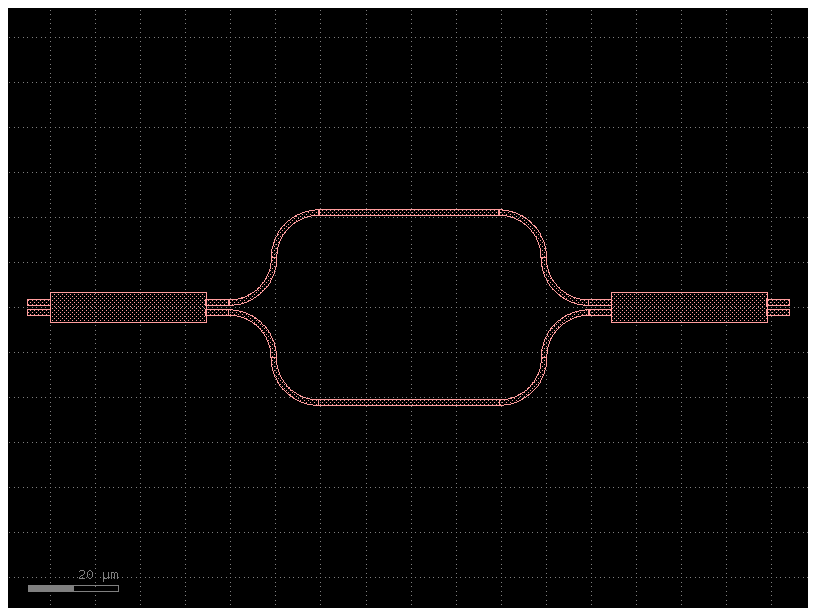

In [111]:
gf.clear_cache()

# =======================================================================
# 1. CELDA DEL MMI 2x2 (Bloque base limpio)
# =======================================================================
@gf.cell
def mmi_2x2_base() -> gf.Component:
    mmi = gf.Component("mmi_2x2_base")
    capa = gf.components.straight().ports["o1"].layer
    sec_acceso = gf.cross_section.cross_section(width=1.2, layer=capa)
    sec_body = gf.cross_section.cross_section(width=6.6, layer=capa)
    
    # Cuerpo del MMI
    longitud_mmi = 69.03598607255596 / 2 
    body = mmi.add_ref(gf.components.straight(length=longitud_mmi, cross_section=sec_body))
    
    # Accesos rectos (1/6 y -1/6)
    pos_y = 6.6 / 6.0  
    l_acc = 5.0
    guia_r = gf.components.straight(length=l_acc, cross_section=sec_acceso)
    
    it = mmi.add_ref(guia_r).movex(-l_acc).movey(pos_y)
    ib = mmi.add_ref(guia_r).movex(-l_acc).movey(-pos_y)
    ot = mmi.add_ref(guia_r).movex(longitud_mmi).movey(pos_y)
    ob = mmi.add_ref(guia_r).movex(longitud_mmi).movey(-pos_y)
    
    mmi.add_port("in_top", port=it.ports["o1"])
    mmi.add_port("in_bot", port=ib.ports["o1"])
    mmi.add_port("out_top", port=ot.ports["o2"])
    mmi.add_port("out_bot", port=ob.ports["o2"])
    return mmi

# =======================================================================
# 2. CONSTRUCCIÓN DEL MZI (Topografía image_e153d4)
# =======================================================================
mzi = gf.Component("MZI_DeltaL_100")

capa_base = gf.components.straight().ports["o1"].layer
width_wg = 1.2
seccion_acceso = gf.cross_section.cross_section(width=width_wg, layer=capa_base)
layer_heater = "HEATER"

# Instanciamos Splitter y Combiner usando nuestro bloque MMI
splitter = mzi.add_ref(mmi_2x2_base())
combiner = mzi.add_ref(mmi_2x2_base())

# Parámetros del interferómetro y de los moduladores térmicos
delta_l = 0         # Desequilibrio total deseado (um)
radius = 10.0              # Radio de curvatura (um)
L_h = 40.0                 # Longitud de la zona recta activa horizontal (um)
ancho_tuner = 2.0          # Ancho de las pistas de metal (um)
gap_tuner = 1.5            # Espacio de aislamiento para que el metal no toque la guía (um)

# Moldes geométricos base
b90 = gf.components.bend_circular(radius=radius, cross_section=seccion_acceso)
guia_horizontal = gf.components.straight(length=L_h, cross_section=seccion_acceso)
guia_vertical_dL = gf.components.straight(length=delta_l / 2.0, cross_section=seccion_acceso)


# --- BRAZO INFERIOR (Camino de referencia corto) ---
b1_bot = mzi.add_ref(b90)
b1_bot.mirror_y()
b1_bot.connect("o1", splitter.ports["out_bot"])

b2_bot = mzi.add_ref(b90)
b2_bot.connect("o1", b1_bot.ports["o2"])

h_bot = mzi.add_ref(guia_horizontal)
h_bot.connect("o1", b2_bot.ports["o2"])

b3_bot = mzi.add_ref(b90)
b3_bot.connect("o1", h_bot.ports["o2"])

b4_bot = mzi.add_ref(b90)
b4_bot.mirror_y()
b4_bot.connect("o1", b3_bot.ports["o2"])

# Fijamos la posición del combiner usando este brazo inferior
combiner.connect("in_bot", b4_bot.ports["o2"])


# --- BRAZO SUPERIOR (Camino largo con tramos DeltaL/2) ---
b1_top = mzi.add_ref(b90)
b1_top.connect("o1", splitter.ports["out_top"])

# Tramo vertical de subida (aporta la primera mitad del desfase: Delta L / 2)
v1_top = mzi.add_ref(guia_vertical_dL)
v1_top.connect("o1", b1_top.ports["o2"])

b2_top = mzi.add_ref(b90)
b2_top.mirror_y()
b2_top.connect("o1", v1_top.ports["o2"])

# Tramo horizontal superior (Misma longitud exacta L_h que el inferior)
h_top = mzi.add_ref(guia_horizontal)
h_top.connect("o1", b2_top.ports["o2"])

b3_top = mzi.add_ref(b90)
b3_top.mirror_y()
b3_top.connect("o1", h_top.ports["o2"])

# Tramo vertical de bajada (aporta la segunda mitad del desfase: Delta L / 2)
v2_top = mzi.add_ref(guia_vertical_dL)
v2_top.connect("o1", b3_top.ports["o2"])

b4_top = mzi.add_ref(b90)
b4_top.connect("o1", v2_top.ports["o2"])

# =======================================================================
# 3. PUERTOS GLOBALES DEL MZI
# =======================================================================
mzi.add_port("in_top", port=splitter.ports["in_top"])
mzi.add_port("in_bot", port=splitter.ports["in_bot"])
mzi.add_port("out_top", port=combiner.ports["out_top"])
mzi.add_port("out_bot", port=combiner.ports["out_bot"])

# ==========================================
# VISUALIZACIÓN
# ==========================================
mzi.plot()
mzi.show()
scene = mzi.to_3d()
scene.show()

Resonador de anillo

2026-06-12 14:01:45.656 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


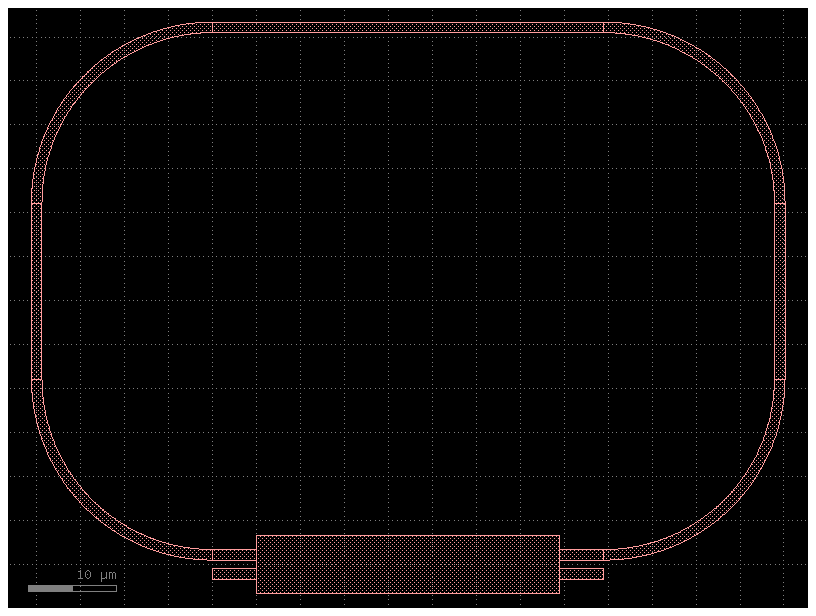

In [112]:
gf.clear_cache()

# Creación del componente principal
resonador_racetrack = gf.Component("Resonador_Racetrack_MMI")

# =======================================================================
# 1. CELDA DEL MMI 2x2 (Bloque de acoplo central)
# =======================================================================
@gf.cell
def mmi_2x2_base() -> gf.Component:
    mmi = gf.Component("mmi_2x2_base")
    capa = gf.components.straight().ports["o1"].layer
    sec_acceso = gf.cross_section.cross_section(width=1.2, layer=capa)
    sec_body = gf.cross_section.cross_section(width=6.6, layer=capa)
    
    longitud_mmi = 69.03598607255596 / 2 
    body = mmi.add_ref(gf.components.straight(length=longitud_mmi, cross_section=sec_body))
    
    pos_y = 6.6 / 6.0  
    l_acc = 5.0
    guia_r = gf.components.straight(length=l_acc, cross_section=sec_acceso)
    
    it = mmi.add_ref(guia_r).movex(-l_acc).movey(pos_y)
    ib = mmi.add_ref(guia_r).movex(-l_acc).movey(-pos_y)
    ot = mmi.add_ref(guia_r).movex(longitud_mmi).movey(pos_y)
    ob = mmi.add_ref(guia_r).movex(longitud_mmi).movey(-pos_y)
    
    mmi.add_port("in_top", port=it.ports["o1"])
    mmi.add_port("in_bot", port=ib.ports["o1"])
    mmi.add_port("out_top", port=ot.ports["o2"])
    mmi.add_port("out_bot", port=ob.ports["o2"])
    return mmi

# =======================================================================
# 2. SECCIONES Y MOLDES GEOMÉTRICOS
# =======================================================================
capa_base = gf.components.straight().ports["o1"].layer
seccion_acceso = gf.cross_section.cross_section(width=1.2, layer=capa_base)

# Añadimos el acoplador MMI central al diseño
mmi_central = resonador_racetrack.add_ref(mmi_2x2_base())

# Parámetros del anillo/racetrack
radius = 20
longitud_vertical = 20.0  # Longitud de los tramos rectos verticales de la pista

# La longitud del tramo horizontal superior debe ser exactamente igual a la distancia
# entre los puertos del MMI (longitud del cuerpo + las dos extensiones de acceso de 5 um)
longitud_horizontal = (69.03598607255596 / 2) + 2 * 5.0

# Creamos las piezas "molde"
b90 = gf.components.bend_circular(radius=radius, cross_section=seccion_acceso)
guia_v = gf.components.straight(length=longitud_vertical, cross_section=seccion_acceso)
guia_h = gf.components.straight(length=longitud_horizontal, cross_section=seccion_acceso)

# =======================================================================
# 3. CONSTRUCCIÓN DEL BUCLE SUPERIOR (RACETRACK)
# =======================================================================
# Esquina inferior derecha: sube desde la salida superior del MMI
b1 = resonador_racetrack.add_ref(b90)
b1.connect("o1", mmi_central.ports["out_top"])

# Recta vertical derecha (subiendo)
v1 = resonador_racetrack.add_ref(guia_v)
v1.connect("o1", b1.ports["o2"])

# Esquina superior derecha: gira hacia la izquierda
b2 = resonador_racetrack.add_ref(b90)
b2.connect("o1", v1.ports["o2"])

# Recta horizontal superior (hacia la izquierda)
h1 = resonador_racetrack.add_ref(guia_h)
h1.connect("o1", b2.ports["o2"])

# Esquina superior izquierda: gira hacia abajo
b3 = resonador_racetrack.add_ref(b90)
b3.connect("o1", h1.ports["o2"])

# Recta vertical izquierda (bajando)
v2 = resonador_racetrack.add_ref(guia_v)
v2.connect("o1", b3.ports["o2"])

# Esquina inferior izquierda: gira a la derecha para cerrar en la entrada superior del MMI
b4 = resonador_racetrack.add_ref(b90)
b4.connect("o1", v2.ports["o2"])


# =======================================================================
# 4. PUERTOS GLOBALES DEL CIRCUITO (Brazo inferior libre)
# =======================================================================
# Tal y como muestra tu imagen, in0 y out0 son los accesos inferiores del bloque
resonador_racetrack.add_port("in0", port=mmi_central.ports["in_bot"])
resonador_racetrack.add_port("out0", port=mmi_central.ports["out_bot"])


# ==========================================
# VISUALIZACIÓN
# ==========================================
resonador_racetrack.plot()
resonador_racetrack.show()
scene = resonador_racetrack.to_3d()
scene.show()

## 2. Layout Fundamentals

A cell is a function that returns a Component. In GDS each component must have a unique name. Two components stored in the GDS file cannot have the same name. They need to be references (instances) of the same component.

![GDSFactoryComponents][def]


[def]: https://i.imgur.com/oeuKGsc.png

2026-06-12 14:01:45.914 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


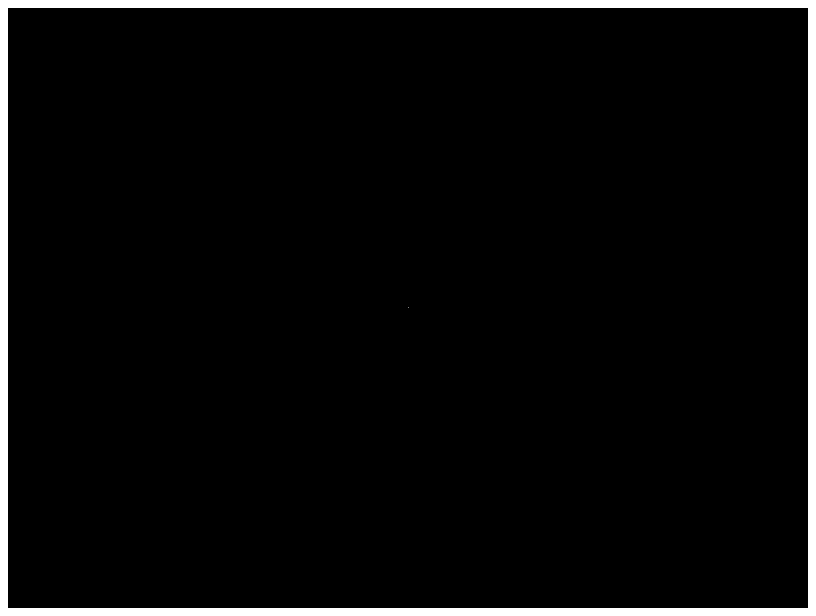

In [113]:
c = gf.Component()
c.plot()
c.show()

Let's build a Component from scratch. A die (chip) for a photonic layout. The PDK or Design Manual should specify the Layer for the bounding box (dicing line). 
We should also consider: 
1. The die dimensions and 
2. The border for dicing 

2026-06-12 14:01:46.090 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


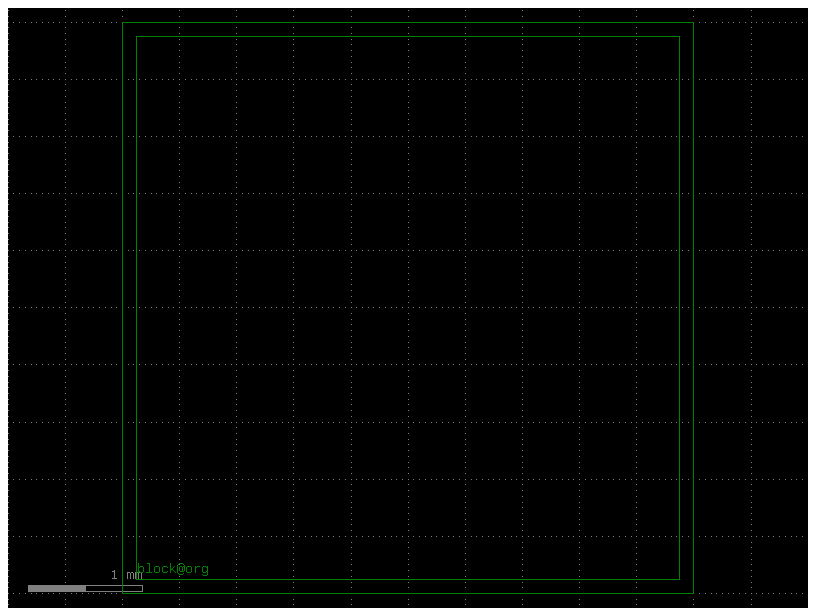

In [114]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

box.draw_ports()
box.show()
box.plot()

### Mantra: 
Once that we have a working 'new' component, we shall convert it into a Cell. This will allow us to have a hierarchical design

2026-06-12 14:01:46.442 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


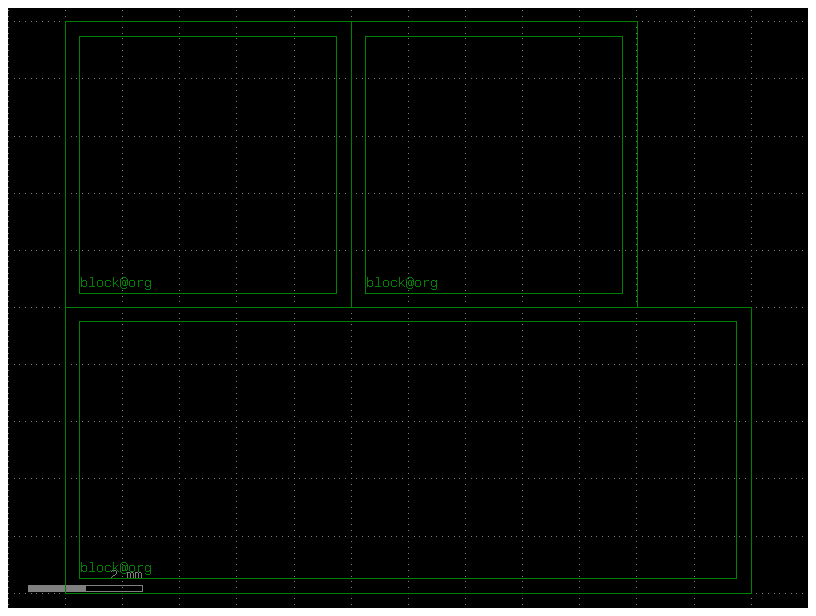

In [115]:
# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
wafer = gf.Component()
dieW1 = 5000
dieW2 = 10000

c1 = wafer.add_ref(die(dieW = dieW))
c2 = wafer.add_ref(die(dieW = dieW))
c3 = wafer.add_ref(die(dieW = 12000))

c2.dmovex(dieW1)
c3.dmovey(-5000)
wafer.show()
wafer.plot()


Layout acoplador direccional

2026-06-12 14:01:46.747 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


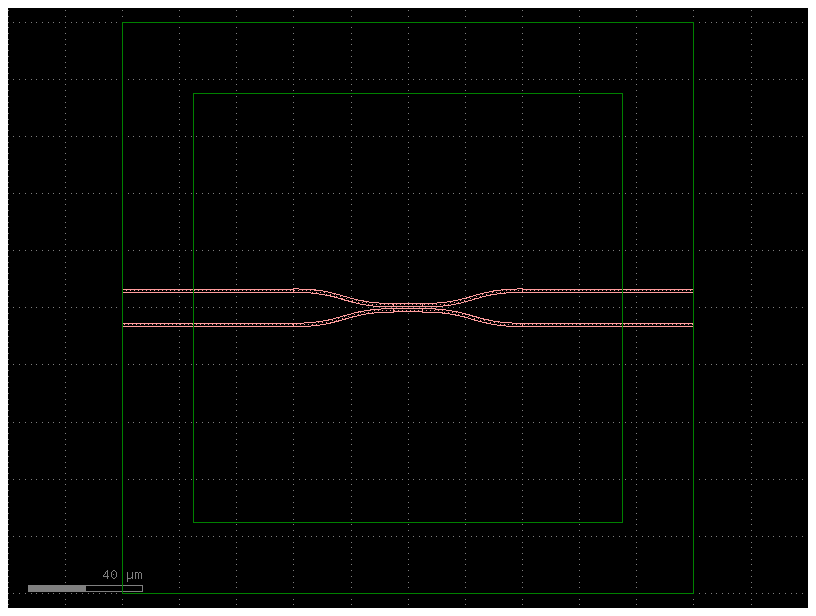

In [116]:
gf.clear_cache()

# =======================================================================
# 1. COMPONENTE ESPECÍFICO (Nivel inferior de la jerarquía)
# =======================================================================
@gf.cell
def acoplador_direccional_base(width: float = 1.2, gap: float = 0.6) -> gf.Component:
    """Genera la estructura óptica pura del acoplador direccional."""
    c = gf.Component("Acoplador_Base")
    
    capa_base = gf.components.straight().ports["o1"].layer
    seccion_300nm = gf.cross_section.cross_section(width=width, layer=capa_base)

    guia_recta = gf.components.straight(length=10, cross_section=seccion_300nm) 

    recta_inferior = c.add_ref(guia_recta)
    recta_superior = c.add_ref(guia_recta)

    separacion_centros = gap + width 
    recta_superior.movey(-separacion_centros)

    distancia_separacion_y = 12.0     
    longitud_transicion = 35.0        

    offset_y = (distancia_separacion_y - separacion_centros) / 2
    s_bend = gf.components.bend_s(size=(longitud_transicion, offset_y), cross_section=seccion_300nm)

    # Conexiones lado izquierdo (Entradas)
    s_in_top = c.add_ref(s_bend)
    s_in_top.connect("o2", recta_superior.ports["o1"]) 

    s_in_bot = c.add_ref(s_bend)
    s_in_bot.mirror_y()
    s_in_bot.connect("o2", recta_inferior.ports["o1"])

    # Conexiones lado derecho (Salidas)
    s_out_top = c.add_ref(s_bend)
    s_out_top.mirror_x() 
    s_out_top.connect("o2", recta_superior.ports["o2"])

    s_out_bot = c.add_ref(s_bend)
    s_out_bot.mirror_y() 
    s_out_bot.mirror_x() 
    s_out_bot.connect("o2", recta_inferior.ports["o2"])

    # Puertos locales del componente específico
    c.add_port("in_top", port=s_in_top.ports["o1"])
    c.add_port("in_bot", port=s_in_bot.ports["o1"])
    c.add_port("out_top", port=s_out_top.ports["o1"])
    c.add_port("out_bot", port=s_out_bot.ports["o1"])
    
    return c


# =======================================================================
# 2. CELDA INTERMEDIA (Nivel medio: Estructura del Die + Extensiones)
# =======================================================================
@gf.cell
def die_acoplador(dieL=200, dieW=200, border=25, layer_box="FLOORPLAN") -> gf.Component:
    """Celda que fabrica el marco perimetral booleano e integra el componente."""
    box = gf.Component("Die_Acoplador_Cell")
    
    # --- Marco del Die (Tu estructura booleana exacta) ---
    obox = box.add_ref(gf.components.rectangle(size=(dieW, dieL), layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW - border * 2, dieL - border * 2), layer=layer_box)).dmovex(border).dmovey(border)
    box_frame = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    box.add_ref(box_frame)

    # Puerto de anclaje de la esquina solicitado
    box.add_port(name="block@org", center=[border, border], width=1, orientation=0, layer=layer_box)

    # --- Instanciamos el acoplador en el centro del Die ---
    acoplador_ref = box.add_ref(acoplador_direccional_base())
    acoplador_ref.center = (dieW / 2, dieL / 2)

    # --- Extensiones de las guías de onda hasta los bordes ---
    capa_base = gf.components.straight().ports["o1"].layer
    seccion_300nm = gf.cross_section.cross_section(width=1.2, layer=capa_base)
    
    # Cálculo automático de distancias a los extremos (X=0 y X=5000)
    longitud_extension_izq = acoplador_ref.ports["in_top"].x
    longitud_extension_der = dieW - acoplador_ref.ports["out_top"].x

    guia_ext_izq = gf.components.straight(length=longitud_extension_izq, cross_section=seccion_300nm)
    guia_ext_der = gf.components.straight(length=longitud_extension_der, cross_section=seccion_300nm)

    # Conectamos las extensiones izquierdas (Entradas hacia el borde X=0)
    ext_in_top = box.add_ref(guia_ext_izq)
    ext_in_top.connect("o2", acoplador_ref.ports["in_top"])

    ext_in_bot = box.add_ref(guia_ext_izq)
    ext_in_bot.connect("o2", acoplador_ref.ports["in_bot"])

    # Conectamos las extensiones derechas (Salidas hacia el borde X=5000)
    ext_out_top = box.add_ref(guia_ext_der)
    ext_out_top.connect("o1", acoplador_ref.ports["out_top"])  # ¡Corregido "o1"!

    ext_out_bot = box.add_ref(guia_ext_der)
    ext_out_bot.connect("o1", acoplador_ref.ports["out_bot"])  # ¡Corregido "o1"!

    # Puertos expuestos finales de la celda del Die
    box.add_port("in_top", port=ext_in_top.ports["o1"])
    box.add_port("in_bot", port=ext_in_bot.ports["o1"])
    box.add_port("out_top", port=ext_out_top.ports["o2"])
    box.add_port("out_bot", port=ext_out_bot.ports["o2"])
    
    return box


# =======================================================================
# 3. COMPONENTE SUPERIOR (Lienzo final / Wafer de la práctica)
# =======================================================================
wafer_layout = gf.Component("Layout_Final_Acoplador")

# Instanciamos la celda intermedia dentro del componente superior
wafer_layout.add_ref(die_acoplador())

# Visualización
wafer_layout.show()
wafer_layout.plot()

Layout MMI 2x2

2026-06-12 14:01:47.047 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


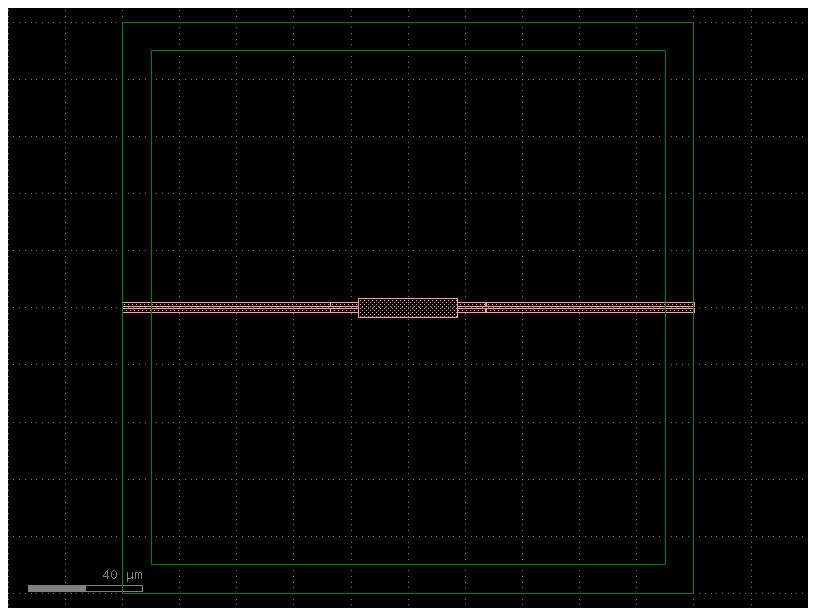

In [117]:
gf.clear_cache()

# =======================================================================
# 1. COMPONENTE ESPECÍFICO (Nivel inferior de la jerarquía)
# =======================================================================
@gf.cell
def mmi_2x2_base(width: float = 1.2, ancho_body: float = 6.6) -> gf.Component:
    """Genera la estructura limpia del MMI 2x2 con accesos rectos a +/- 1/6."""
    c = gf.Component("MMI_2x2_Base")
    
    capa_base = gf.components.straight().ports["o1"].layer
    seccion_acceso = gf.cross_section.cross_section(width=width, layer=capa_base)
    seccion_body = gf.cross_section.cross_section(width=ancho_body, layer=capa_base)
    
    # 1. Cuerpo central del MMI (Interferencia pareada: L = L_pi / 2)
    L_pi = 69.03598607255596
    longitud_mmi = L_pi / 2 
    cuerpo = gf.components.straight(length=longitud_mmi, cross_section=seccion_body)
    c.add_ref(cuerpo)
    
    # 2. Guías de acceso rectas cortas (rabillos de 10 um)
    posicion_y = ancho_body / 6.0  # Posiciones exactas a 1/6 y -1/6
    longitud_acceso = 10.0  
    guia_recta_acceso = gf.components.straight(length=longitud_acceso, cross_section=seccion_acceso)
    
    # --- LADO IZQUIERDO (Entradas en X = 0) ---
    in_top = c.add_ref(guia_recta_acceso)
    in_top.movex(-longitud_acceso)
    in_top.movey(posicion_y)
    
    in_bot = c.add_ref(guia_recta_acceso)
    in_bot.movex(-longitud_acceso)
    in_bot.movey(-posicion_y)
    
    # --- LADO DERECHO (Salidas en X = longitud_mmi) ---
    out_top = c.add_ref(guia_recta_acceso)
    out_top.movex(longitud_mmi)
    out_top.movey(posicion_y)
    
    out_bot = c.add_ref(guia_recta_acceso)
    out_bot.movex(longitud_mmi)
    out_bot.movey(-posicion_y)
    
    # Puertos locales expuestos del MMI limpio
    c.add_port("in_top", port=in_top.ports["o1"])
    c.add_port("in_bot", port=in_bot.ports["o1"])
    c.add_port("out_top", port=out_top.ports["o2"])
    c.add_port("out_bot", port=out_bot.ports["o2"])
    
    return c


# =======================================================================
# 2. CELDA INTERMEDIA (Nivel medio: Estructura del Die + Extensiones)
# =======================================================================
@gf.cell
def die_mmi(dieL=200, dieW=200, border=10, layer_box="FLOORPLAN") -> gf.Component:
    """Celda que fabrica el marco booleano del chip e integra el MMI centrado."""
    box = gf.Component("Die_MMI_Cell")
    
    # --- Marco del Die (Tu estructura booleana exacta) ---
    obox = box.add_ref(gf.components.rectangle(size=(dieW, dieL), layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW - border * 2, dieL - border * 2), layer=layer_box)).dmovex(border).dmovey(border)
    box_frame = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    box.add_ref(box_frame)

    # Puerto de anclaje de la esquina solicitado en tu especificación
    box.add_port(name="block@org", center=[border, border], width=1, orientation=0, layer=layer_box)

    # --- Instanciamos el MMI en el centro del Die ---
    mmi_ref = box.add_ref(mmi_2x2_base())
    mmi_ref.center = (dieW / 2, dieL / 2)

    # --- Extensiones de las guías de onda largas hasta los bordes del chip ---
    capa_base = gf.components.straight().ports["o1"].layer
    seccion_300nm = gf.cross_section.cross_section(width=1.2, layer=capa_base)
    
    # Cálculo dinámico de distancias a los extremos (X=0 y X=5000)
    longitud_extension_izq = mmi_ref.ports["in_top"].x
    longitud_extension_der = dieW - mmi_ref.ports["out_top"].x

    guia_ext_izq = gf.components.straight(length=longitud_extension_izq, cross_section=seccion_300nm)
    guia_ext_der = gf.components.straight(length=longitud_extension_der, cross_section=seccion_300nm)

    # Conectamos las extensiones izquierdas (Entradas hacia el borde X=0)
    ext_in_top = box.add_ref(guia_ext_izq)
    ext_in_top.connect("o2", mmi_ref.ports["in_top"])

    ext_in_bot = box.add_ref(guia_ext_izq)
    ext_in_bot.connect("o2", mmi_ref.ports["in_bot"])

    # Conectamos las extensiones derechas (Salidas hacia el borde X=5000)
    ext_out_top = box.add_ref(guia_ext_der)
    ext_out_top.connect("o1", mmi_ref.ports["out_top"])

    ext_out_bot = box.add_ref(guia_ext_der)
    ext_out_bot.connect("o1", mmi_ref.ports["out_bot"])

    # Puertos expuestos finales de la celda del Die
    box.add_port("in_top", port=ext_in_top.ports["o1"])
    box.add_port("in_bot", port=ext_in_bot.ports["o1"])
    box.add_port("out_top", port=ext_out_top.ports["o2"])
    box.add_port("out_bot", port=ext_out_bot.ports["o2"])
    
    return box


# =======================================================================
# 3. COMPONENTE SUPERIOR (Lienzo final / Wafer de la práctica)
# =======================================================================
wafer_layout = gf.Component("Layout_Final_MMI")

# Instanciamos la celda intermedia dentro del componente superior
wafer_layout.add_ref(die_mmi())

# Visualización del chip completo
wafer_layout.show()
wafer_layout.plot()

Layout MZI

2026-06-12 16:26:50.298 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


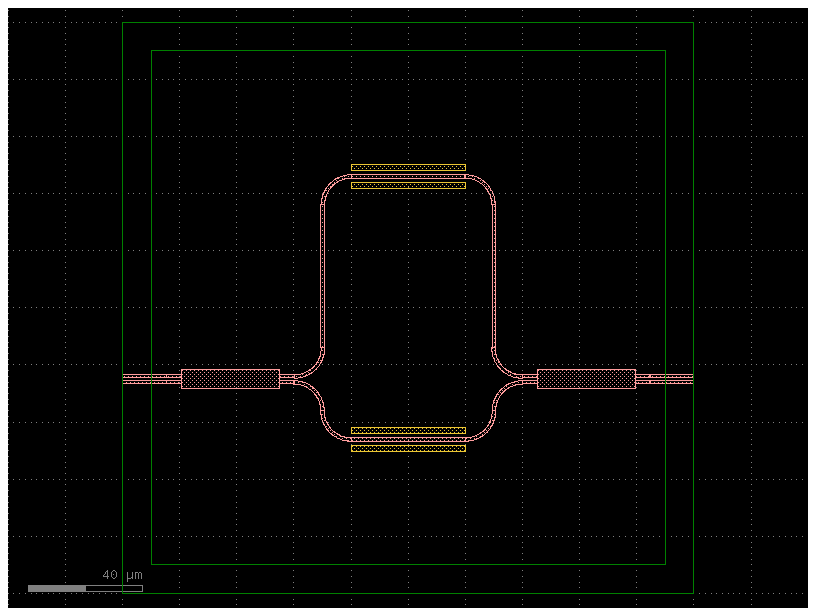

In [ ]:
gf.clear_cache()

# =======================================================================
# 1. COMPONENTES ESPECÍFICOS (Nivel inferior de la jerarquía)
# =======================================================================
@gf.cell
def mmi_2x2_base() -> gf.Component:
    """Sub-bloque específico: MMI 2x2 limpio utilizado como splitter/combiner."""
    mmi = gf.Component("MMI_2x2_Base")
    capa = gf.components.straight().ports["o1"].layer
    sec_acceso = gf.cross_section.cross_section(width=1.2, layer=capa)
    sec_body = gf.cross_section.cross_section(width=6.6, layer=capa)
    
    longitud_mmi = 69.03598607255596 / 2 
    body = mmi.add_ref(gf.components.straight(length=longitud_mmi, cross_section=sec_body))
    
    pos_y = 6.6 / 6.0  
    l_acc = 5.0
    guia_r = gf.components.straight(length=l_acc, cross_section=sec_acceso)
    
    it = mmi.add_ref(guia_r).movex(-l_acc).movey(pos_y)
    ib = mmi.add_ref(guia_r).movex(-l_acc).movey(-pos_y)
    ot = mmi.add_ref(guia_r).movex(longitud_mmi).movey(pos_y)
    ob = mmi.add_ref(guia_r).movex(longitud_mmi).movey(-pos_y)
    
    mmi.add_port("in_top", port=it.ports["o1"])
    mmi.add_port("in_bot", port=ib.ports["o1"])
    mmi.add_port("out_top", port=ot.ports["o2"])
    mmi.add_port("out_bot", port=ob.ports["o2"])
    return mmi


@gf.cell
def mzi_base(
    radius: float = 10.0, 
    delta_l: float = 100.0, 
    L_h: float = 40.0, 
    ancho_tuner: float = 2.0, 
    gap_tuner: float = 1.5
) -> gf.Component:
    """
    Componente específico: Estructura óptica del MZI con calentadores 
    horizontales paralelos flanqueando las guías según el esquema físico.
    """
    c = gf.Component("MZI_Base")
    
    width_wg = 1.2
    layer_wg = gf.components.straight().ports["o1"].layer
    seccion_acceso = gf.cross_section.cross_section(width=width_wg, layer=layer_wg)
    layer_heater = "HEATER" 

    # Instanciamos los bloques MMI internos
    splitter = c.add_ref(mmi_2x2_base())
    combiner = c.add_ref(mmi_2x2_base())

    # Codo de 90° común
    b90 = gf.components.bend_circular(radius=radius, cross_section=seccion_acceso)

    # Moldes de guías rectas horizontales y verticales
    guia_horizontal = gf.components.straight(length=L_h, cross_section=seccion_acceso)
    guia_vertical_dL = gf.components.straight(length=delta_l / 2.0, cross_section=seccion_acceso)

    # --- BRAZO INFERIOR (Camino corto de referencia) ---
    b1_bot = c.add_ref(b90)
    b1_bot.mirror_y()
    b1_bot.connect("o1", splitter.ports["out_bot"])

    b2_bot = c.add_ref(b90)
    b2_bot.connect("o1", b1_bot.ports["o2"])

    h_bot = c.add_ref(guia_horizontal)
    h_bot.connect("o1", b2_bot.ports["o2"])

    b3_bot = c.add_ref(b90)
    b3_bot.connect("o1", h_bot.ports["o2"])

    b4_bot = c.add_ref(b90)
    b4_bot.mirror_y()
    b4_bot.connect("o1", b3_bot.ports["o2"])

    # Conectamos geométricamente el combiner al brazo inferior fijo
    combiner.connect("in_bot", b4_bot.ports["o2"])

    # --- BRAZO SUPERIOR (Camino largo con tramos DeltaL/2) ---
    b1_top = c.add_ref(b90)
    b1_top.connect("o1", splitter.ports["out_top"])

    v1_top = c.add_ref(guia_vertical_dL)
    v1_top.connect("o1", b1_top.ports["o2"])

    b2_top = c.add_ref(b90)
    b2_top.mirror_y()
    b2_top.connect("o1", v1_top.ports["o2"])

    h_top = c.add_ref(guia_horizontal)
    h_top.connect("o1", b2_top.ports["o2"])

    b3_top = c.add_ref(b90)
    b3_top.mirror_y()
    b3_top.connect("o1", h_top.ports["o2"])

    v2_top = c.add_ref(guia_vertical_dL)
    v2_top.connect("o1", b3_top.ports["o2"])

    b4_top = c.add_ref(b90)
    b4_top.connect("o1", v2_top.ports["o2"])

    # --- THERMAL TUNERS HORIZONTALES (Rodeando la guía sin tocarla) ---
    offset = (width_wg / 2.0) + gap_tuner + (ancho_tuner / 2.0)
    tuner_rect = gf.components.rectangle(size=(L_h, ancho_tuner), layer=layer_heater)

    # Calentadores del Brazo Superior (Flanquean horizontalmente a h_top)
    t_top_above = c.add_ref(tuner_rect); t_top_above.center = h_top.center; t_top_above.movey(offset)
    t_top_below = c.add_ref(tuner_rect); t_top_below.center = h_top.center; t_top_below.movey(-offset)

    # Calentadores del Brazo Inferior (Flanquean horizontalmente a h_bot)
    t_bot_above = c.add_ref(tuner_rect); t_bot_above.center = h_bot.center; t_bot_above.movey(offset)
    t_bot_below = c.add_ref(tuner_rect); t_bot_below.center = h_bot.center; t_bot_below.movey(-offset)

    # Puertos locales del MZI
    c.add_port("in_top", port=splitter.ports["in_top"])
    c.add_port("in_bot", port=splitter.ports["in_bot"])
    c.add_port("out_top", port=combiner.ports["out_top"])
    c.add_port("out_bot", port=combiner.ports["out_bot"])
    
    return c


# =======================================================================
# 2. CELDA INTERMEDIA (Nivel medio: Estructura del Die + Extensiones)
# =======================================================================
@gf.cell
def die_mzi(dieL=200, dieW=200, border=10, layer_box="FLOORPLAN") -> gf.Component:
    """Celda que fabrica el marco booleano del chip e integra el MZI centrado."""
    box = gf.Component("Die_MZI_Cell")
    
    # --- Marco del Die (Tu estructura booleana exacta) ---
    obox = box.add_ref(gf.components.rectangle(size=(dieW, dieL), layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW - border * 2, dieL - border * 2), layer=layer_box)).dmovex(border).dmovey(border)
    box_frame = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    box.add_ref(box_frame)

    # Puerto de anclaje de la esquina solicitado
    box.add_port(name="block@org", center=[border, border], width=1, orientation=0, layer=layer_box)

    # --- Instanciamos el MZI con tuners en el centro del Die ---
    mzi_ref = box.add_ref(mzi_base())
    mzi_ref.center = (dieW / 2, dieL / 2)

    # --- Extensiones de las guías de onda largas hasta los bordes del chip ---
    capa_base = gf.components.straight().ports["o1"].layer
    seccion_300nm = gf.cross_section.cross_section(width=1.2, layer=capa_base)
    
    # Cálculo dinámico de distancias a los extremos (X=0 y X=200)
    longitud_extension_izq = mzi_ref.ports["in_top"].x
    longitud_extension_der = dieW - mzi_ref.ports["out_top"].x

    guia_ext_izq = gf.components.straight(length=longitud_extension_izq, cross_section=seccion_300nm)
    guia_ext_der = gf.components.straight(length=longitud_extension_der, cross_section=seccion_300nm)

    # Conectamos las extensiones izquierdas (Entradas hacia el borde X=0)
    ext_in_top = box.add_ref(guia_ext_izq)
    ext_in_top.connect("o2", mzi_ref.ports["in_top"])

    ext_in_bot = box.add_ref(guia_ext_izq)
    ext_in_bot.connect("o2", mzi_ref.ports["in_bot"])

    # Conectamos las extensiones derechas (Salidas hacia el borde X=200)
    ext_out_top = box.add_ref(guia_ext_der)
    ext_out_top.connect("o1", mzi_ref.ports["out_top"])

    ext_out_bot = box.add_ref(guia_ext_der)
    ext_out_bot.connect("o1", mzi_ref.ports["out_bot"])

    # Puertos expuestos finales de la celda del Die
    box.add_port("in_top", port=ext_in_top.ports["o1"])
    box.add_port("in_bot", port=ext_in_bot.ports["o1"])
    box.add_port("out_top", port=ext_out_top.ports["o2"])
    box.add_port("out_bot", port=ext_out_bot.ports["o2"])
    
    return box


# =======================================================================
# 3. COMPONENTE SUPERIOR (Lienzo final / Wafer de la práctica)
# =======================================================================
wafer_layout = gf.Component("Layout_Final_MZI")

# Instanciamos la celda intermedia dentro del componente superior
wafer_layout.add_ref(die_mzi())

# Visualización del chip completo
wafer_layout.show()
wafer_layout.plot()

Layout Resonador de anillo

2026-06-12 14:01:47.685 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


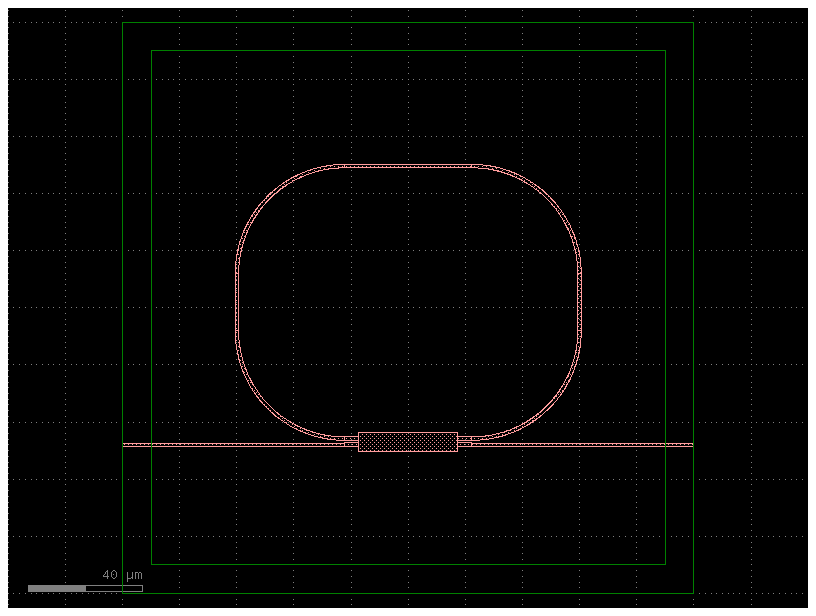

In [119]:
gf.clear_cache()

# =======================================================================
# 1. COMPONENTES ESPECÍFICOS (Nivel inferior de la jerarquía)
# =======================================================================
@gf.cell
def mmi_2x2_base() -> gf.Component:
    """Sub-bloque específico: MMI 2x2 limpio utilizado como acoplador del anillo."""
    mmi = gf.Component("MMI_2x2_Base")
    capa = gf.components.straight().ports["o1"].layer
    sec_acceso = gf.cross_section.cross_section(width=1.2, layer=capa)
    sec_body = gf.cross_section.cross_section(width=6.6, layer=capa)
    
    longitud_mmi = 69.03598607255596 / 2 
    body = mmi.add_ref(gf.components.straight(length=longitud_mmi, cross_section=sec_body))
    
    pos_y = 6.6 / 6.0  
    l_acc = 5.0
    guia_r = gf.components.straight(length=l_acc, cross_section=sec_acceso)
    
    it = mmi.add_ref(guia_r).movex(-l_acc).movey(pos_y)
    ib = mmi.add_ref(guia_r).movex(-l_acc).movey(-pos_y)
    ot = mmi.add_ref(guia_r).movex(longitud_mmi).movey(pos_y)
    ob = mmi.add_ref(guia_r).movex(longitud_mmi).movey(-pos_y)
    
    mmi.add_port("in_top", port=it.ports["o1"])
    mmi.add_port("in_bot", port=ib.ports["o1"])
    mmi.add_port("out_top", port=ot.ports["o2"])
    mmi.add_port("out_bot", port=ob.ports["o2"])
    return mmi


@gf.cell
def resonador_racetrack_base(radius: float = 37.69, longitud_vertical: float = 20.0) -> gf.Component:
    """Componente específico: Cavidad racetrack cerrada sobre el MMI central."""
    c = gf.Component("Resonador_Racetrack_Base")
    
    capa_base = gf.components.straight().ports["o1"].layer
    seccion_acceso = gf.cross_section.cross_section(width=1.2, layer=capa_base)

    # Añadimos el acoplador MMI central al sub-diseño
    mmi_central = c.add_ref(mmi_2x2_base())

    # La longitud del tramo horizontal superior debe ser igual a la distancia total entre puertos
    longitud_horizontal = (69.03598607255596 / 2) + 2 * 5.0

    # Moldes geométricos para la pista de carreras
    b90 = gf.components.bend_circular(radius=radius, cross_section=seccion_acceso)
    guia_v = gf.components.straight(length=longitud_vertical, cross_section=seccion_acceso)
    guia_h = gf.components.straight(length=longitud_horizontal, cross_section=seccion_acceso)

    # --- CONSTRUCCIÓN DEL BUCLE SUPERIOR (Cierre de la cavidad) ---
    # Esquina inferior derecha: sube desde la salida superior del MMI
    b1 = c.add_ref(b90)
    b1.connect("o1", mmi_central.ports["out_top"])

    # Recta vertical derecha (subiendo)
    v1 = c.add_ref(guia_v)
    v1.connect("o1", b1.ports["o2"])

    # Esquina superior derecha: gira hacia la izquierda
    b2 = c.add_ref(b90)
    b2.connect("o1", v1.ports["o2"])

    # Recta horizontal superior (hacia la izquierda)
    h1 = c.add_ref(guia_h)
    h1.connect("o1", b2.ports["o2"])

    # Esquina superior izquierda: gira hacia abajo
    b3 = c.add_ref(b90)
    b3.connect("o1", h1.ports["o2"])

    # Recta vertical izquierda (bajando)
    v2 = c.add_ref(guia_v)
    v2.connect("o1", b3.ports["o2"])

    # Esquina inferior izquierda: cierra el bucle en la entrada superior del MMI
    b4 = c.add_ref(b90)
    b4.connect("o1", v2.ports["o2"])

    # Puertos locales del resonador (Los brazos inferiores libres del MMI, in0 y out0 de tu imagen)
    c.add_port("in0", port=mmi_central.ports["in_bot"])
    c.add_port("out0", port=mmi_central.ports["out_bot"])
    
    return c


# =======================================================================
# 2. CELDA INTERMEDIA (Nivel medio: Estructura del Die + Extensiones)
# =======================================================================
@gf.cell
def die_resonador(dieL=200, dieW=200, border=10, layer_box="FLOORPLAN") -> gf.Component:
    """Celda que fabrica el marco booleano del chip e integra el Resonador centrado."""
    box = gf.Component("Die_Resonador_Cell")
    
    # --- Marco del Die (Tu estructura booleana exacta) ---
    obox = box.add_ref(gf.components.rectangle(size=(dieW, dieL), layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW - border * 2, dieL - border * 2), layer=layer_box)).dmovex(border).dmovey(border)
    box_frame = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    box.add_ref(box_frame)

    # Puerto de anclaje de la esquina solicitado
    box.add_port(name="block@org", center=[border, border], width=1, orientation=0, layer=layer_box)

    # --- Instanciamos el Resonador en el centro del Die ---
    racetrack_ref = box.add_ref(resonador_racetrack_base())
    racetrack_ref.center = (dieW / 2, dieL / 2)

    # --- Extensiones de las guías de paso (Bus) hasta los bordes del chip ---
    capa_base = gf.components.straight().ports["o1"].layer
    seccion_300nm = gf.cross_section.cross_section(width=1.2, layer=capa_base)
    
    # Cálculo dinámico de distancias a los extremos desde la guía inferior del MMI (X=0 y X=5000)
    longitud_extension_izq = racetrack_ref.ports["in0"].x
    longitud_extension_der = dieW - racetrack_ref.ports["out0"].x

    guia_ext_izq = gf.components.straight(length=longitud_extension_izq, cross_section=seccion_300nm)
    guia_ext_der = gf.components.straight(length=longitud_extension_der, cross_section=seccion_300nm)

    # Conectamos las extensiones izquierdas (Entrada in0 hacia el borde X=0)
    ext_in = box.add_ref(guia_ext_izq)
    ext_in.connect("o2", racetrack_ref.ports["in0"])

    # Conectamos las extensiones derechas (Salida out0 hacia el borde X=5000)
    ext_out = box.add_ref(guia_ext_der)
    ext_out.connect("o1", racetrack_ref.ports["out0"])

    # Puertos expuestos finales de la celda del Die (Consistente con tu imagen)
    box.add_port("in0", port=ext_in.ports["o1"])
    box.add_port("out0", port=ext_out.ports["o2"])
    
    return box


# =======================================================================
# 3. COMPONENTE SUPERIOR (Lienzo final / Wafer de la práctica)
# =======================================================================
wafer_layout = gf.Component("Layout_Final_Resonador")

# Instanciamos la celda intermedia dentro del componente superior
wafer_layout.add_ref(die_resonador())

# Visualización del chip completo
wafer_layout.show()
wafer_layout.plot()

## 3. Complete Layout

2026-06-12 14:01:48.026 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


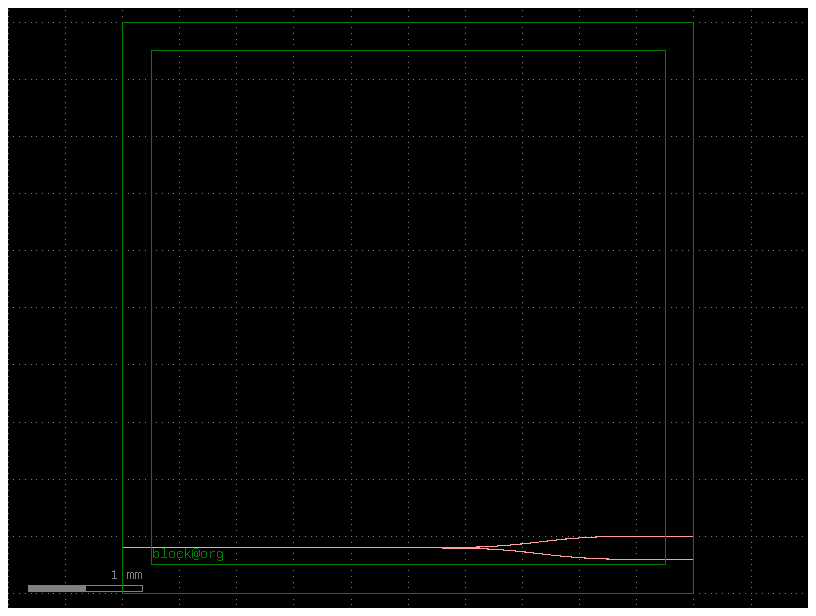

In [120]:
layer_wg  = "WG"
minrad = 50
dieW = 5000

main = gf.Component()

die_ref = main.add_ref(die(dieW = dieW, layer_box="FLOORPLAN"))

## Add first a test MMI routed from side to side
c_mmi = cells.mmi1x2()
mmi = main.add_ref(c_mmi)
mmi.dmovex(die_ref["block@org"].dx + 0.5*dieW).dmovey(die_ref['block@org'].dy + 150)

## Route waveguides from MMI to the die edges
xs = 'strip'
### First add the i/o waveguides - to be sure you 'cut' on a straight section
strin = (main.add_ref(gf.components.straight(length=500, cross_section='strip')).dmovex(0).dmovey(mmi['o1'].dy))
strout1 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o3'].dy-100).dmovex(dieW))
strout2 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o2'].dy+100).dmovex(dieW))
### Then route from the i/o waveguides to the MMI
gf.routing.route_single_sbend(main,port1=strin['o2'], port2=mmi['o1'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o2'], port2=strout2['o2'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o3'], port2=strout1['o2'], cross_section=xs)

main.plot()
main.show()

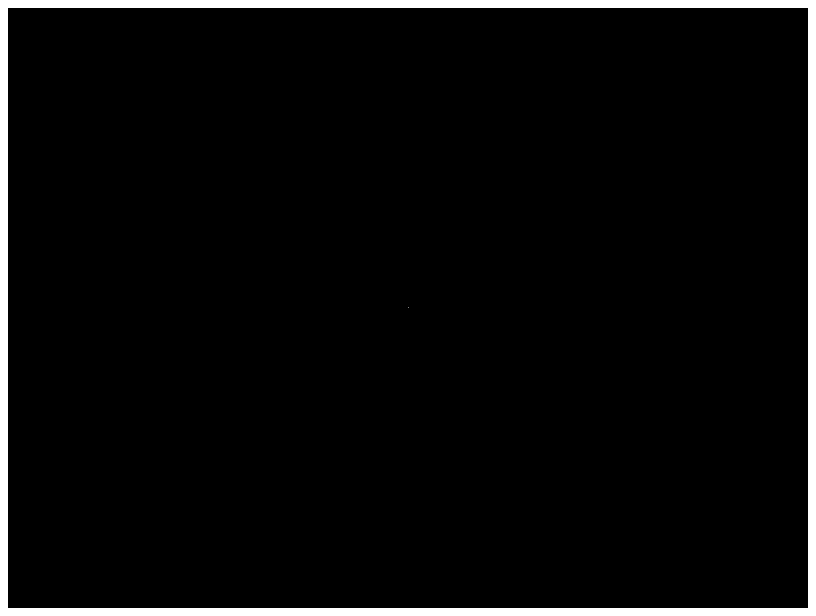

In [121]:
# Let's create a MMI tree

c = gf.Component()
c_mmi = cells.mmi1x2()
...
c.plot()

In [122]:
# Once we "test" the high-level component, we can create a cell for it
@gf.cell 
def mmi_tree_1x4(pad_x = 250 ,pad_y = 250):
    c = gf.Component()
    c_mmi = cells.mmi1x2()
    mmi1 = c.add_ref(c_mmi)
    mmi2 = c.add_ref(c_mmi)
    mmi3 = c.add_ref(c_mmi)

    mmi2.dmovex(pad_x).dmovey(pad_y)
    mmi3.dmovex(pad_x).dmovey(-pad_y)

    gf.routing.route_single_sbend(component=c, port1= mmi1['o2'], port2=mmi2['o1'],cross_section='strip')
    gf.routing.route_single_sbend(component=c, port1= mmi1['o3'], port2=mmi3['o1'],cross_section='strip')
    c.add_port(name='o1', port=mmi1['o1'])
    c.add_port(name='o2', port=mmi2['o2'])
    c.add_port(name='o3', port=mmi2['o3'])
    c.add_port(name='o4', port=mmi3['o2'])
    c.add_port(name='o5', port=mmi3['o3'])
    c.draw_ports()
    return c

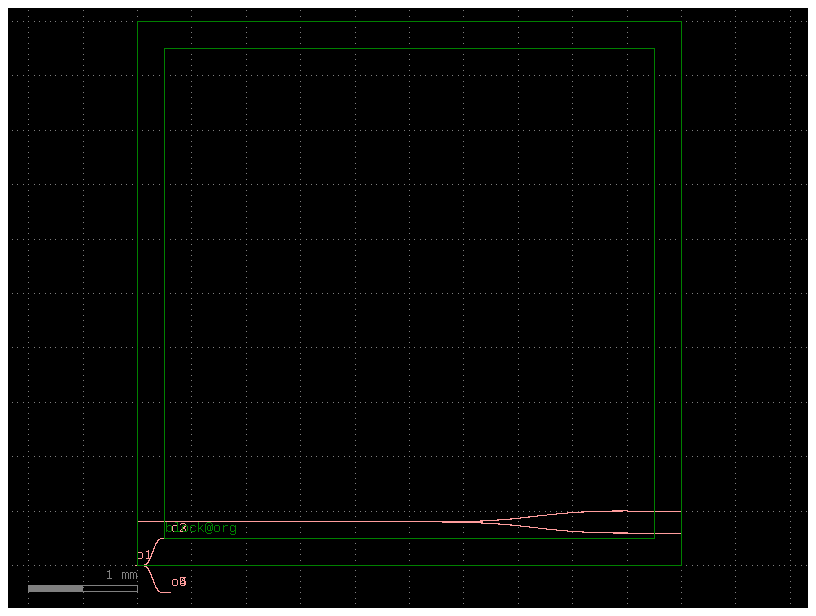

In [ ]:
# With the cell created, we can instantiate and use it in our main component

cell_1x4 = main.add_ref(mmi_tree_1x4())
main.plot()


2026-06-12 14:01:48.741 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


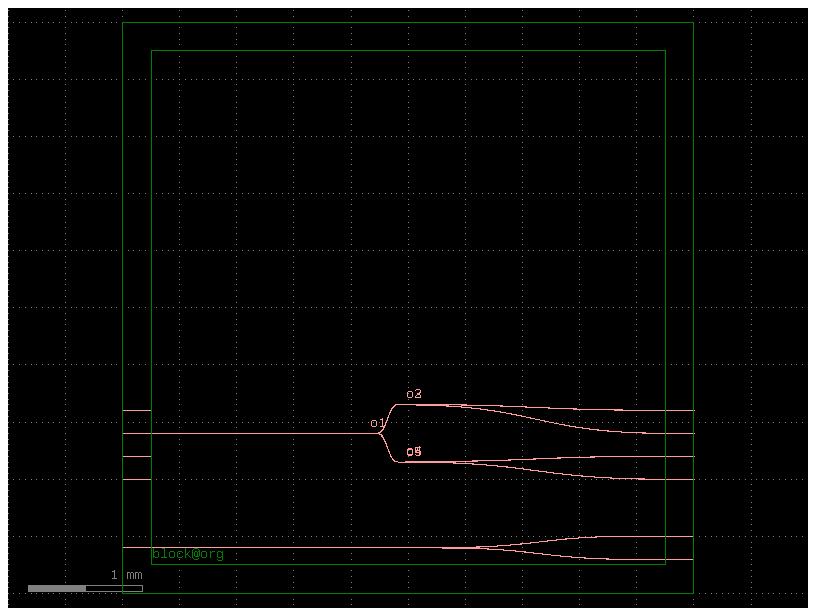

In [124]:
## Arrayed waveguides and MMI tree

sp = 200
border = 250

in_arr = main.add_ref(
    gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
).dmovey(
    1000
)  #!!!!!! Easy to put IO Waveguides for a complete design !!!!

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)

cell_1x4.dmovex(0.5*dieW - mmi_tree_1x4().dxsize).dmovey(in_arr['o6'].dy)
gf.routing.route_single_sbend(component=main, port1=in_arr['o6'], port2=cell_1x4['o1'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o2'], port2=out_arr['o4'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o3'], port2=out_arr['o3'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o4'], port2=out_arr['o2'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o5'], port2=out_arr['o1'])
main.plot()
main.show()

### Mantra:
It's useful to use memorize this mantra: 
- Add_references 
- Connect_them
- Move_them

### Other Routing options examples:

Please check the GDSFactory Routing API for more information about advanced routing functionalities

[Routing API](https://gdsfactory.github.io/gdsfactory/api_routing.html) 

## 4. Exercises. 

Part a) Creating components
- Create a cell component for a unbalanced MZI, using 2x2 50:50 MMIs with arm length difference as parameter
- Create a cell component based on the previous, where the arms have thermal tuners on top of each one
- Create a cell component for an all-pass ring resonator, using 2x2 50:50 MMIs, with extra length parameter for different perimeters
- Create a cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter
- Create a cell component based on existing GDSfactory spiral components, with length as parameter

Part b) Creating die
- Create a die  W = 5 mm x L = 10 mm 
- Create an array of I/Os spaced at 250 µm (as much I/Os as the width allows)
- Create a cell component of this die, with I/Os accessible to connect

Part c) Floorplaning and die layout
- Make an instance of the die as host component for your layout
- Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die
- Add 2 of each of the components above, with different lengths
- Connect all your components to the I/Os 

Ejercicio 4a) 1

2026-06-12 14:01:49.038 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


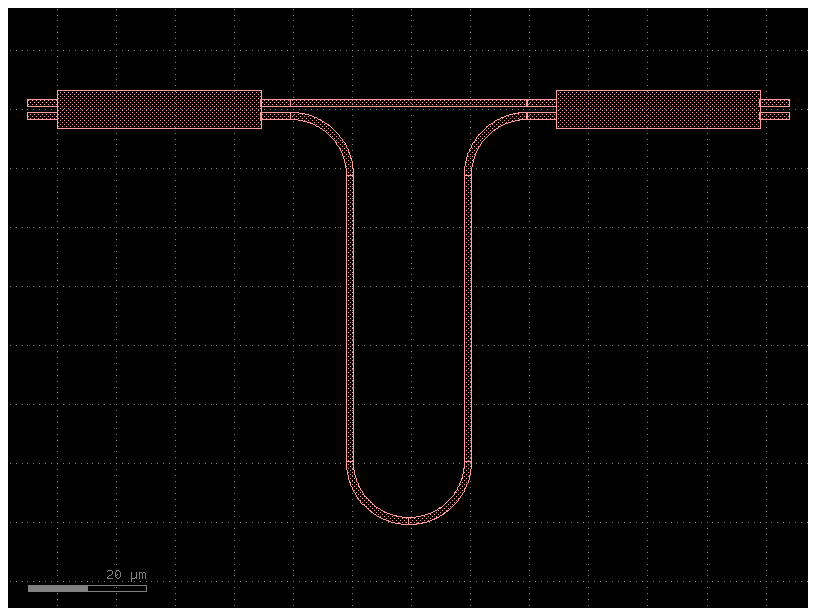

In [125]:
gf.clear_cache()

# =======================================================================
# 1. SUB-BLOQUE: MMI 2x2 50:50 (Reutilizado como Splitter/Combiner)
# =======================================================================
@gf.cell
def mmi_2x2_50_50() -> gf.Component:
    """Genera el bloque MMI 2x2 de interferencia pareada."""
    mmi = gf.Component("MMI_2x2_50_50")
    capa = gf.components.straight().ports["o1"].layer
    sec_acceso = gf.cross_section.cross_section(width=1.2, layer=capa)
    sec_body = gf.cross_section.cross_section(width=6.6, layer=capa)
    
    longitud_mmi = 69.03598607255596 / 2 
    body = mmi.add_ref(gf.components.straight(length=longitud_mmi, cross_section=sec_body))
    
    pos_y = 6.6 / 6.0  
    l_acc = 5.0
    guia_r = gf.components.straight(length=l_acc, cross_section=sec_acceso)
    
    it = mmi.add_ref(guia_r).movex(-l_acc).movey(pos_y)
    ib = mmi.add_ref(guia_r).movex(-l_acc).movey(-pos_y)
    ot = mmi.add_ref(guia_r).movex(longitud_mmi).movey(pos_y)
    ob = mmi.add_ref(guia_r).movex(longitud_mmi).movey(-pos_y)
    
    mmi.add_port("in_top", port=it.ports["o1"])
    mmi.add_port("in_bot", port=ib.ports["o1"])
    mmi.add_port("out_top", port=ot.ports["o2"])
    mmi.add_port("out_bot", port=ob.ports["o2"])
    return mmi


@gf.cell
def mzi_unbalanced(delta_l: float = 100.0, radius: float = 10.0) -> gf.Component:
    """Argumentos:
        delta_l: Diferencia de longitud deseada entre los dos brazos (um).
        radius: Radio de curvatura de los codos (um).
    """
    c = gf.Component(f"MZI_unbalanced_dL_{delta_l}")
    
    capa_base = gf.components.straight().ports["o1"].layer
    seccion_acceso = gf.cross_section.cross_section(width=1.2, layer=capa_base)

    # Instanciamos los dos bloques MMI 2x2 50:50
    splitter = c.add_ref(mmi_2x2_50_50())
    combiner = c.add_ref(mmi_2x2_50_50())

    # Codos circulares de 90 grados
    b90 = gf.components.bend_circular(radius=radius, cross_section=seccion_acceso)
    L_bend = b90.info.get("length", 0.5 * 3.1415926535 * radius)

    # Ecuación analítica para ajustar el desfase exacto (delta_l) en el bucle
    L_v = (delta_l / 2.0) + (2.0 * radius) - (2.0 * L_bend)

    # Moldes de guías rectas según las dimensiones calculadas
    guia_vertical = gf.components.straight(length=L_v, cross_section=seccion_acceso)
    guia_superior = gf.components.straight(length=4.0 * radius, cross_section=seccion_acceso)

    # --- BRAZO INFERIOR (Brazo largo con retardo óptico) ---
    b1 = c.add_ref(b90)
    b1.mirror_y()
    b1.connect("o1", splitter.ports["out_bot"])

    v1 = c.add_ref(guia_vertical)
    v1.connect("o1", b1.ports["o2"])

    b2 = c.add_ref(b90)
    b2.connect("o1", v1.ports["o2"])

    b3 = c.add_ref(b90)
    b3.connect("o1", b2.ports["o2"])

    v2 = c.add_ref(guia_vertical)
    v2.connect("o1", b3.ports["o2"])

    b4 = c.add_ref(b90)
    b4.mirror_y()
    b4.connect("o1", v2.ports["o2"])

    # Fijamos el combiner al extremo de la trayectoria larga
    combiner.connect("in_bot", b4.ports["o2"])

    # --- BRAZO SUPERIOR (Brazo corto con longitud base) ---
    t1 = c.add_ref(guia_superior)
    t1.connect("o1", splitter.ports["out_top"])

    # Puertos globales del componente de celda MZI
    c.add_port("in_top", port=splitter.ports["in_top"])
    c.add_port("in_bot", port=splitter.ports["in_bot"])
    c.add_port("out_top", port=combiner.ports["out_top"])
    c.add_port("out_bot", port=combiner.ports["out_bot"])
    
    return c


# 3. VISUALIZACIÓN Y GENERACIÓN DE LA GRÁFICA
if __name__ == "__main__":
    # Instanciamos la celda pasando el parámetro requerido, por ejemplo Delta_L = 120 um
    componente_mzi = mzi_unbalanced(delta_l=120.0)
    
    # Genera la gráfica y abre la celda en KLayout
    componente_mzi.plot()
    componente_mzi.show()

Ejercicio 4a) 2

2026-06-12 14:01:49.314 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


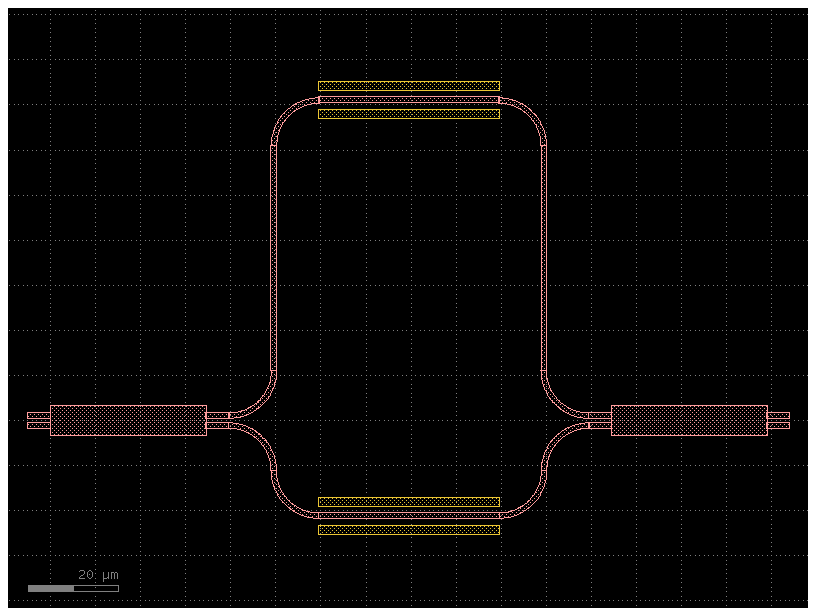

In [126]:
gf.clear_cache()

# =======================================================================
# 1. SUB-BLOQUE: MMI 2x2 50:50 (Divisor/Combinador - Tu diseño base)
# =======================================================================
@gf.cell
def mmi_2x2_50_50() -> gf.Component:
    mmi = gf.Component("MMI_2x2_50_50")
    capa = gf.components.straight().ports["o1"].layer
    sec_acceso = gf.cross_section.cross_section(width=1.2, layer=capa)
    sec_body = gf.cross_section.cross_section(width=6.6, layer=capa)
    
    longitud_mmi = 69.03598607255596 / 2 
    body = mmi.add_ref(gf.components.straight(length=longitud_mmi, cross_section=sec_body))
    
    pos_y = 6.6 / 6.0  
    l_acc = 5.0
    guia_r = gf.components.straight(length=l_acc, cross_section=sec_acceso)
    
    it = mmi.add_ref(guia_r).movex(-l_acc).movey(pos_y)
    ib = mmi.add_ref(guia_r).movex(-l_acc).movey(-pos_y)
    ot = mmi.add_ref(guia_r).movex(longitud_mmi).movey(pos_y)
    ob = mmi.add_ref(guia_r).movex(longitud_mmi).movey(-pos_y)
    
    mmi.add_port("in_top", port=it.ports["o1"])
    mmi.add_port("in_bot", port=ib.ports["o1"])
    mmi.add_port("out_top", port=ot.ports["o2"])
    mmi.add_port("out_bot", port=ob.ports["o2"])
    return mmi


# =======================================================================
# 2. COMPONENTE REQUERIDO: MZI SEGÚN ESQUEMA COINCIDENTE (image_e153d4)
# =======================================================================
@gf.cell
def mzi_with_horizontal_tuners(
    delta_l: float = 100.0, 
    radius: float = 10.0, 
    L_h: float = 40.0,         # Longitud de la zona activa horizontal (L_h)
    ancho_tuner: float = 2.0,   # Ancho de la pista metálica
    gap_tuner: float = 1.5      # Espacio de seguridad para no tocar la guía
) -> gf.Component:
    
    c = gf.Component(f"MZI_horizontal_tuners_dL_{delta_l}")
    
    width_wg = 1.2
    layer_wg = gf.components.straight().ports["o1"].layer
    seccion_acceso = gf.cross_section.cross_section(width=width_wg, layer=layer_wg)
    layer_heater = "HEATER" 

    # Instanciamos Splitter y Combiner
    splitter = c.add_ref(mmi_2x2_50_50())
    combiner = c.add_ref(mmi_2x2_50_50())

    # Codo de 90° común
    b90 = gf.components.bend_circular(radius=radius, cross_section=seccion_acceso)

    # Moldes de guías rectas horizontales y verticales
    guia_horizontal = gf.components.straight(length=L_h, cross_section=seccion_acceso)
    guia_vertical_dL = gf.components.straight(length=delta_l / 2.0, cross_section=seccion_acceso)

    # -------------------------------------------------------------------
    # BRAZO INFERIOR (Camino de referencia corto con calentador horizontal)
    # -------------------------------------------------------------------
    b1_bot = c.add_ref(b90)
    b1_bot.mirror_y()
    b1_bot.connect("o1", splitter.ports["out_bot"])

    b2_bot = c.add_ref(b90)
    b2_bot.connect("o1", b1_bot.ports["o2"])

    h_bot = c.add_ref(guia_horizontal)
    h_bot.connect("o1", b2_bot.ports["o2"])

    b3_bot = c.add_ref(b90)
    b3_bot.connect("o1", h_bot.ports["o2"])

    b4_bot = c.add_ref(b90)
    b4_bot.mirror_y()
    b4_bot.connect("o1", b3_bot.ports["o2"])

    # El combiner se alinea arrastrado por este brazo inferior
    combiner.connect("in_bot", b4_bot.ports["o2"])


    # -------------------------------------------------------------------
    # BRAZO SUPERIOR (Brazo largo con tramos DeltaL/2 y calentador horizontal)
    # -------------------------------------------------------------------
    b1_top = c.add_ref(b90)
    b1_top.connect("o1", splitter.ports["out_top"])

    # Tramo vertical de subida (Delta L / 2)
    v1_top = c.add_ref(guia_vertical_dL)
    v1_top.connect("o1", b1_top.ports["o2"])

    b2_top = c.add_ref(b90)
    b2_top.mirror_y()
    b2_top.connect("o1", v1_top.ports["o2"])

    # Tramo horizontal superior (Misma longitud L_h)
    h_top = c.add_ref(guia_horizontal)
    h_top.connect("o1", b2_top.ports["o2"])

    b3_top = c.add_ref(b90)
    b3_top.mirror_y()
    b3_top.connect("o1", h_top.ports["o2"])

    # Tramo vertical de bajada (Delta L / 2)
    v2_top = c.add_ref(guia_vertical_dL)
    v2_top.connect("o1", b3_top.ports["o2"])

    b4_top = c.add_ref(b90)
    b4_top.connect("o1", v2_top.ports["o2"])


    # -------------------------------------------------------------------
    # THERMAL TUNERS HORIZONTALES (Rodeando la guía sin tocarla)
    # -------------------------------------------------------------------
    offset = (width_wg / 2.0) + gap_tuner + (ancho_tuner / 2.0)
    tuner_rect = gf.components.rectangle(size=(L_h, ancho_tuner), layer=layer_heater)

    # Calentadores del Brazo Superior (Flanquean horizontalmente a h_top)
    t_top_above = c.add_ref(tuner_rect); t_top_above.center = h_top.center; t_top_above.movey(offset)
    t_top_below = c.add_ref(tuner_rect); t_top_below.center = h_top.center; t_top_below.movey(-offset)

    # Calentadores del Brazo Inferior (Flanquean horizontalmente a h_bot)
    t_bot_above = c.add_ref(tuner_rect); t_bot_above.center = h_bot.center; t_bot_above.movey(offset)
    t_bot_below = c.add_ref(tuner_rect); t_bot_below.center = h_bot.center; t_bot_below.movey(-offset)


    # Puertos globales del MZI
    c.add_port("in_top", port=splitter.ports["in_top"])
    c.add_port("in_bot", port=splitter.ports["in_bot"])
    c.add_port("out_top", port=combiner.ports["out_top"])
    c.add_port("out_bot", port=combiner.ports["out_bot"])
    
    return c


# =======================================================================
# 3. EJECUCIÓN Y CONTROL DE VISUALIZACIÓN
# =======================================================================
if __name__ == "__main__":
    # Instanciamos el diseño con la topografía exacta de tu ejercicio
    mzi_final = mzi_with_horizontal_tuners(delta_l=100.0, L_h=40.0)
    mzi_final.plot()
    mzi_final.show()

Ejercicio 4a) 3

2026-06-12 14:01:49.604 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


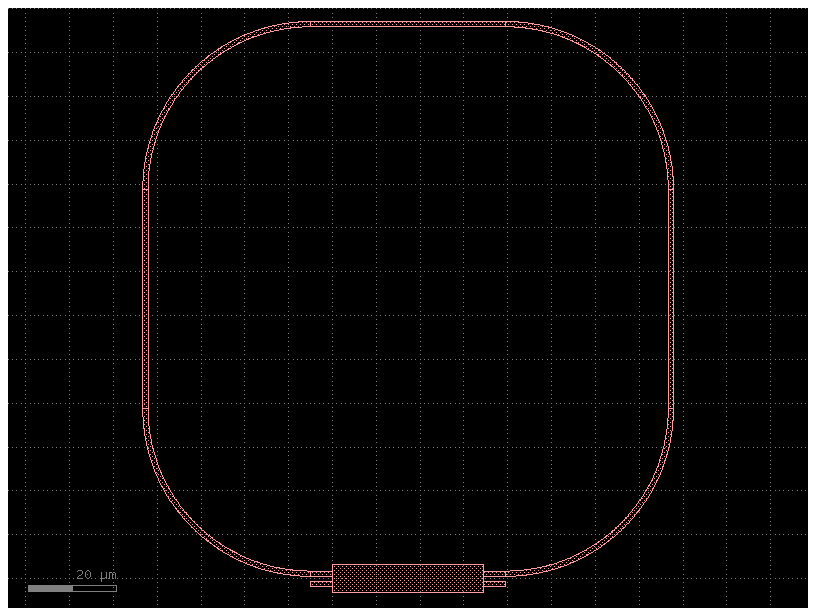

In [127]:
gf.clear_cache()

# =======================================================================
# 1. CELDA DEL MMI 2x2 (Bloque base limpio)
# =======================================================================
@gf.cell
def mmi_2x2_base() -> gf.Component:
    mmi = gf.Component("mmi_2x2_base")
    capa = gf.components.straight().ports["o1"].layer
    sec_acceso = gf.cross_section.cross_section(width=1.2, layer=capa)
    sec_body = gf.cross_section.cross_section(width=6.6, layer=capa)
    
    # Cuerpo del MMI
    longitud_mmi = 69.03598607255596 / 2 
    body = mmi.add_ref(gf.components.straight(length=longitud_mmi, cross_section=sec_body))
    
    # Accesos rectos (1/6 y -1/6)
    pos_y = 6.6 / 6.0  
    l_acc = 5.0
    guia_r = gf.components.straight(length=l_acc, cross_section=sec_acceso)
    
    it = mmi.add_ref(guia_r).movex(-l_acc).movey(pos_y)
    ib = mmi.add_ref(guia_r).movex(-l_acc).movey(-pos_y)
    ot = mmi.add_ref(guia_r).movex(longitud_mmi).movey(pos_y)
    ob = mmi.add_ref(guia_r).movex(longitud_mmi).movey(-pos_y)
    
    mmi.add_port("in_top", port=it.ports["o1"])
    mmi.add_port("in_bot", port=ib.ports["o1"])
    mmi.add_port("out_top", port=ot.ports["o2"])
    mmi.add_port("out_bot", port=ob.ports["o2"])
    return mmi


# =======================================================================
# 2. CONSTRUCCIÓN DEL RESONADOR DE ANILLO CON PARÁMETRO EXTRA_LENGTH
# =======================================================================
@gf.cell
def ring_allpass_mmi(radius: float = 37.69, extra_length: float = 50.0) -> gf.Component:
    """
    Genera un resonador de anillo (all-pass) acoplado a un MMI 2x2.
    
    Args:
        radius: Radio de curvatura de los codos (um).
        extra_length: Longitud adicional total para incrementar el perímetro (um).
    """
    c = gf.Component(f"Ring_AllPass_Radius_{radius}_extra_{extra_length}")
    
    capa_base = gf.components.straight().ports["o1"].layer
    seccion_acceso = gf.cross_section.cross_section(width=1.2, layer=capa_base)

    # Añadimos el acoplador MMI central al diseño
    mmi_central = c.add_ref(mmi_2x2_base())

    # Altura base de los tramos verticales + la mitad de la longitud extra en cada lado
    longitud_vertical = 20.0 + (extra_length / 2.0)
    
    # La longitud horizontal es fija para encajar exactamente con los puertos del MMI
    longitud_horizontal = (69.03598607255596 / 2) + 2 * 5.0

    # Creamos los moldes de las piezas
    b90 = gf.components.bend_circular(radius=radius, cross_section=seccion_acceso)
    guia_v = gf.components.straight(length=longitud_vertical, cross_section=seccion_acceso)
    guia_h = gf.components.straight(length=longitud_horizontal, cross_section=seccion_acceso)

    # --- CONSTRUCCIÓN DEL BUCLE (Pista de carreras) ---
    # 1. Esquina inferior derecha: nace en la salida superior del MMI y apunta hacia arriba
    b1 = c.add_ref(b90)
    b1.connect("o1", mmi_central.ports["out_top"])

    # 2. Tramo vertical derecho (aporta extra_length / 2 al perímetro)
    v1 = c.add_ref(guia_v)
    v1.connect("o1", b1.ports["o2"])

    # 3. Esquina superior derecha: gira hacia la izquierda
    b2 = c.add_ref(b90)
    b2.connect("o1", v1.ports["o2"])

    # 4. Tramo horizontal superior
    h1 = c.add_ref(guia_h)
    h1.connect("o1", b2.ports["o2"])

    # 5. Esquina superior izquierda: gira hacia abajo
    b3 = c.add_ref(b90)
    b3.connect("o1", h1.ports["o2"])

    # 6. Tramo vertical izquierdo (aporta el otro extra_length / 2 al perímetro)
    v2 = c.add_ref(guia_v)
    v2.connect("o1", b3.ports["o2"])

    # 7. Esquina inferior izquierda: cierra el bucle perfectamente en la entrada superior del MMI
    b4 = c.add_ref(b90)
    b4.connect("o1", v2.ports["o2"])

    # =======================================================================
    # 3. PUERTOS GLOBALES DEL COMPONENTE ISLADO
    # =======================================================================
    # Los puertos de paso directo (bus) son los accesos inferiores del MMI
    c.add_port("in0", port=mmi_central.ports["in_bot"])
    c.add_port("out0", port=mmi_central.ports["out_bot"])
    
    return c


# ==========================================
# VISUALIZACIÓN
# ==========================================
if __name__ == "__main__":
    # Instanciamos el componente aislado con una longitud extra de ejemplo (ej. 60 um)
    resonador_anillo = ring_allpass_mmi(radius=37.69, extra_length=60.0)
    
    resonador_anillo.plot()
    resonador_anillo.show()
    scene = resonador_anillo.to_3d()
    scene.show()

Ejercicio 4a) 4

2026-06-12 14:01:49.937 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


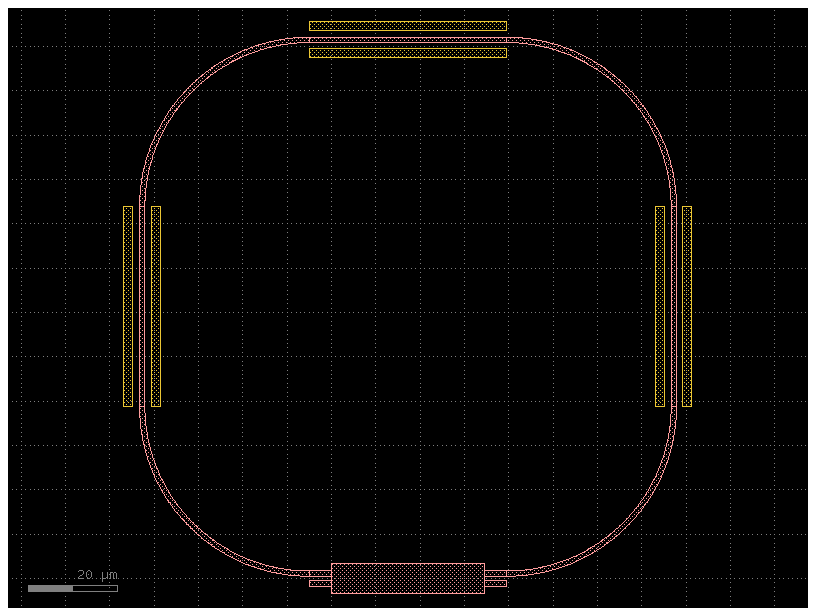

In [128]:
gf.clear_cache()

# =======================================================================
# 1. CELDA DEL MMI 2x2 (Bloque base limpio)
# =======================================================================
@gf.cell
def mmi_2x2_base() -> gf.Component:
    mmi = gf.Component("mmi_2x2_base")
    capa = gf.components.straight().ports["o1"].layer
    sec_acceso = gf.cross_section.cross_section(width=1.2, layer=capa)
    sec_body = gf.cross_section.cross_section(width=6.6, layer=capa)
    
    # Cuerpo del MMI
    longitud_mmi = 69.03598607255596 / 2 
    body = mmi.add_ref(gf.components.straight(length=longitud_mmi, cross_section=sec_body))
    
    # Accesos rectos (1/6 y -1/6)
    pos_y = 6.6 / 6.0  
    l_acc = 5.0
    guia_r = gf.components.straight(length=l_acc, cross_section=sec_acceso)
    
    it = mmi.add_ref(guia_r).movex(-l_acc).movey(pos_y)
    ib = mmi.add_ref(guia_r).movex(-l_acc).movey(-pos_y)
    ot = mmi.add_ref(guia_r).movex(longitud_mmi).movey(pos_y)
    ob = mmi.add_ref(guia_r).movex(longitud_mmi).movey(-pos_y)
    
    mmi.add_port("in_top", port=it.ports["o1"])
    mmi.add_port("in_bot", port=ib.ports["o1"])
    mmi.add_port("out_top", port=ot.ports["o2"])
    mmi.add_port("out_bot", port=ob.ports["o2"])
    return mmi


# =======================================================================
# 2. CONSTRUCCIÓN DEL RESONADOR DE ANILLO CON THERMAL TUNERS
# =======================================================================
@gf.cell
def ring_allpass_with_tuners(
    radius: float = 37.69, 
    extra_length: float = 50.0,
    ancho_tuner: float = 2.0,   # Ancho de la pista de metal
    gap_tuner: float = 1.5      # Espacio de seguridad para no tocar la guía
) -> gf.Component:
    
    c = gf.Component(f"Ring_Thermal_Radius_{radius}")
    
    width_wg = 1.2
    layer_wg = gf.components.straight().ports["o1"].layer
    seccion_acceso = gf.cross_section.cross_section(width=width_wg, layer=layer_wg)
    layer_heater = "HEATER"

    # Añadimos el acoplador MMI central al diseño
    mmi_central = c.add_ref(mmi_2x2_base())

    # Dimensiones de las guías del anillo
    longitud_vertical = 20.0 + (extra_length / 2.0)
    longitud_horizontal = (69.03598607255596 / 2) + 2 * 5.0

    # Moldes de las piezas de la guía de onda
    b90 = gf.components.bend_circular(radius=radius, cross_section=seccion_acceso)
    guia_v = gf.components.straight(length=longitud_vertical, cross_section=seccion_acceso)
    guia_h = gf.components.straight(length=longitud_horizontal, cross_section=seccion_acceso)

    # --- CONSTRUCCIÓN DEL BUCLE ÓPTICO ---
    b1 = c.add_ref(b90); b1.connect("o1", mmi_central.ports["out_top"])
    v1 = c.add_ref(guia_v); v1.connect("o1", b1.ports["o2"])
    b2 = c.add_ref(b90); b2.connect("o1", v1.ports["o2"])
    h1 = c.add_ref(guia_h); h1.connect("o1", b2.ports["o2"])
    b3 = c.add_ref(b90); b3.connect("o1", h1.ports["o2"])
    v2 = c.add_ref(guia_v); v2.connect("o1", b3.ports["o2"])
    b4 = c.add_ref(b90); b4.connect("o1", v2.ports["o2"])


    # --- ADICIÓN DE THERMAL TUNERS EN PARALELO (SIN TOCAR LA GUÍA) ---
    # Calculamos el desplazamiento neto desde el centro de la guía al centro del metal
    offset = (width_wg / 2.0) + gap_tuner + (ancho_tuner / 2.0)

    # Moldes de los rectángulos de metal
    tuner_horizontal = gf.components.rectangle(size=(longitud_horizontal, ancho_tuner), layer=layer_heater)
    tuner_vertical = gf.components.rectangle(size=(ancho_tuner, longitud_vertical), layer=layer_heater)

    # 1. Calentadores del tramo superior (Flanquean horizontalmente a h1)
    th_above = c.add_ref(tuner_horizontal); th_above.center = h1.center; th_above.movey(offset)
    th_below = c.add_ref(tuner_horizontal); th_below.center = h1.center; th_below.movey(-offset)

    # 2. Calentadores del tramo derecho (Flanquean verticalmente a v1)
    tv1_left = c.add_ref(tuner_vertical); tv1_left.center = v1.center; tv1_left.movex(-offset)
    tv1_right = c.add_ref(tuner_vertical); tv1_right.center = v1.center; tv1_right.movex(offset)

    # 3. Calentadores del tramo izquierdo (Flanquean verticalmente a v2)
    tv2_left = c.add_ref(tuner_vertical); tv2_left.center = v2.center; tv2_left.movex(-offset)
    tv2_right = c.add_ref(tuner_vertical); tv2_right.center = v2.center; tv2_right.movex(offset)


    # --- PUERTOS GLOBALES DEL COMPONENTE ISLADO ---
    c.add_port("in0", port=mmi_central.ports["in_bot"])
    c.add_port("out0", port=mmi_central.ports["out_bot"])
    
    return c


# ==========================================
# VISUALIZACIÓN
# ==========================================
if __name__ == "__main__":
    # Instanciamos el componente aislado con los calentadores perimetrales paralelos
    resonador_termico = ring_allpass_with_tuners(radius=37.69, extra_length=50.0)
    
    resonador_termico.plot()
    resonador_termico.show()
    scene = resonador_termico.to_3d()
    scene.show()

Ejercicio 4a) 5

2026-06-12 14:01:50.331 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


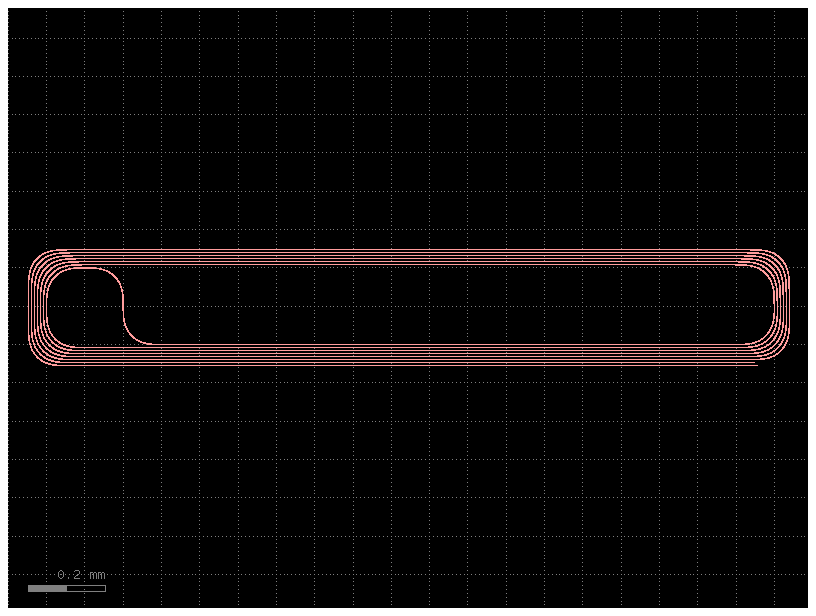

In [129]:
gf.clear_cache()

# =======================================================================
# 5. COMPONENTE REQUERIDO: ESPIRAL FOTÓNICA CORREGIDA (COMPATIBLE)
# =======================================================================
@gf.cell
def spiral_with_length_param(
    length: float = 1000.0,  # Longitud total objetivo de la guía en um
    spacing: float = 10.0    # Distancia entre guías adyacentes de la espiral
) -> gf.Component:
    """
    Genera una celda de espiral fotónica utilizando el componente nativo de 
    GDSfactory, parametrizando su longitud total de guía de onda.
    """
    c = gf.Component(f"Spiral_Component_L_{length}um")
    
    # Extraemos la capa tecnológica del PDK
    capa_base = gf.components.straight().ports["o1"].layer
    seccion_acceso = gf.cross_section.cross_section(width=1.2, layer=capa_base)

    # Instanciamos la espiral nativa eliminando el parámetro 'gap' problemático
    espiral_nativa = gf.components.spiral(
        length=length,
        spacing=spacing,
        cross_section=seccion_acceso
    )
    
    # Añadimos la espiral como una referencia al componente de celda
    espiral_ref = c.add_ref(espiral_nativa)
    
    # Heredamos jerárquicamente todos los puertos del bloque nativo hacia fuera
    c.add_ports(espiral_ref.ports)
    
    return c


# ==========================================
# VISUALIZACIÓN DEL COMPONENTE AISLADO
# ==========================================
if __name__ == "__main__":
    # Ejecutamos pasando solo los parámetros completamente válidos en tu entorno
    componente_espiral = spiral_with_length_param(length=1500.0, spacing=8.0)
    
    componente_espiral.plot()
    componente_espiral.show()

Ejercicio 4b) 1

2026-06-12 14:01:50.577 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


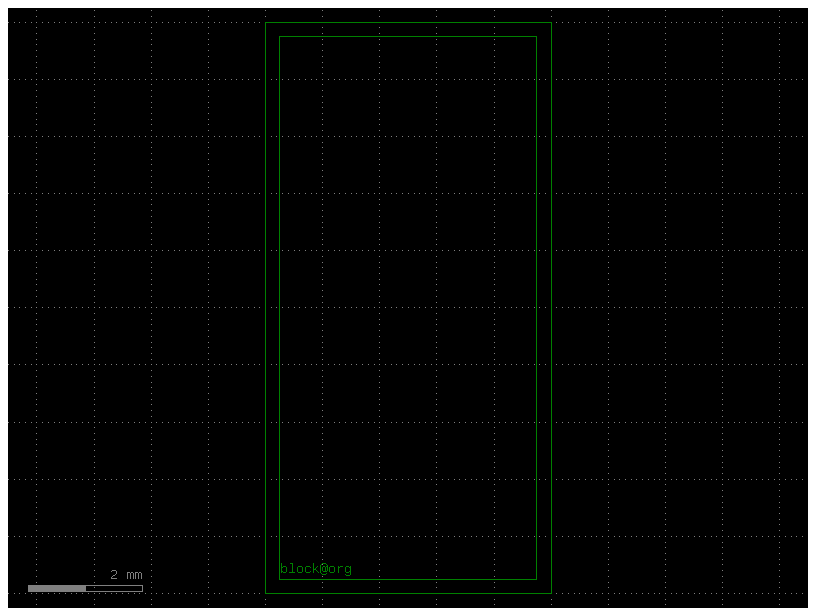

In [130]:
@gf.cell
def die_5x10mm_base(dieW: float = 5000.0, dieL: float = 10000.0, border: float = 250.0, layer_box: str = "FLOORPLAN") -> gf.Component:
    """
    Genera el marco perimetral del Die principal con dimensiones de 5mm x 10mm 
    aplicando una resta booleana.
    """
    box = gf.Component("Die_5x10mm_Base")
    
    # 1. Rectángulo exterior completo (5000 x 10000 um)
    obox = box.add_ref(gf.components.rectangle(size=(dieW, dieL), layer=layer_box))
    
    # 2. Rectángulo interior restando el margen de seguridad de los bordes
    ibox = box.add_ref(gf.components.rectangle(size=(dieW - border * 2, dieL - border * 2), layer=layer_box))
    ibox.dmovex(border).dmovey(border)
    
    # 3. Resta booleana para generar el canal del marco
    box_frame = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    box.add_ref(box_frame)
    
    # Puerto de anclaje de referencia en la esquina interna del borde
    box.add_port(name="block@org", center=[border, border], width=1, orientation=0, layer=layer_box)
    
    box.draw_ports()
    return box


if __name__ == "__main__":
    # Visualización aislada del contenedor del chip de 5x10 mm
    die_principal = die_5x10mm_base()
    die_principal.plot()
    die_principal.show()

Ejercicio 4b) 2

2026-06-12 14:01:50.821 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


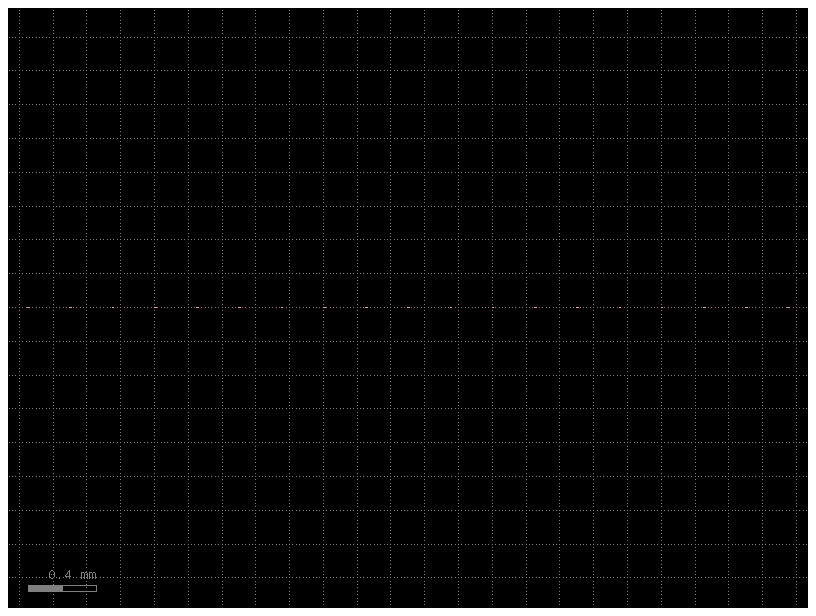

In [131]:
@gf.cell
def io_port_array(
    dieW: float = 5000.0, 
    border: float = 250.0, 
    pitch: float = 250.0, 
    width_wg: float = 1.2
) -> gf.Component:
    """
    Crea una fila de terminales de guías de onda (I/Os) espaciados a 250 um
    ocupando todo el ancho disponible dentro de los márgenes del Die.
    """
    c = gf.Component("Array_IO_Ports")
    
    capa_base = gf.components.straight().ports["o1"].layer
    seccion = gf.cross_section.cross_section(width=width_wg, layer=capa_base)
    
    # Cada I/O se representa inicialmente con un terminal recto corto de 10 um
    longitud_terminal = 10.0
    terminal_molde = gf.components.straight(length=longitud_terminal, cross_section=seccion)
    
    # Calculamos cuántos puertos caben exactamente en el espacio interno
    ancho_disponible = dieW - (2 * border)
    num_ios = int(ancho_disponible / pitch) + 1
    
    # Colocamos los puertos en fila india partiendo desde el límite del borde izquierdo (X = border)
    for i in range(num_ios):
        pos_x = border + (i * pitch)
        
        # Instanciamos el terminal de acoplo
        io_ref = c.add_ref(terminal_molde)
        io_ref.movex(pos_x)
        
        # Añadimos y renombramos el puerto de forma secuencial para la jerarquía superior
        c.add_port(name=f"io_{i}", port=io_ref.ports["o1"])
        
    return c


if __name__ == "__main__":
    # Visualización aislada de la fila de 19 puertos de entrada/salida fotónicos
    array_ios = io_port_array()
    array_ios.plot()
    array_ios.show()

Ejercicio 4b) 3

2026-06-12 14:01:51.104 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


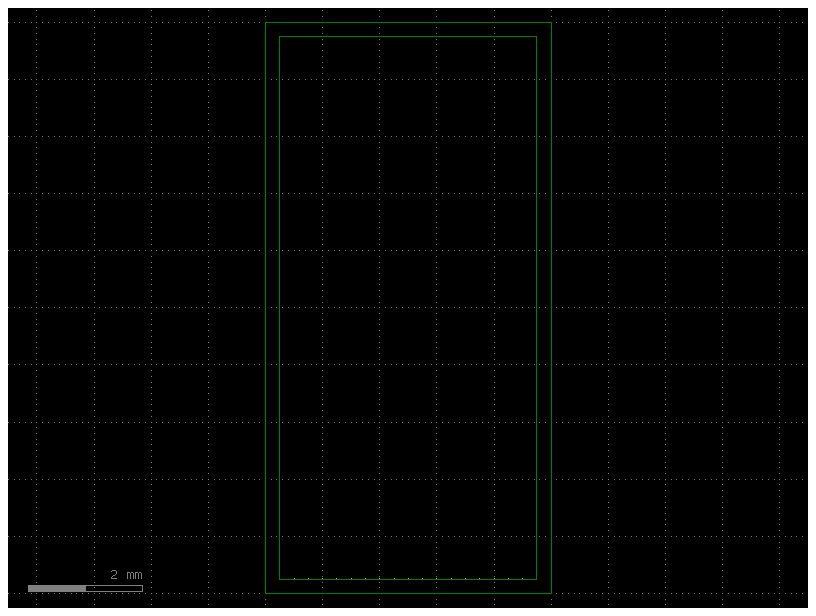

In [132]:
gf.clear_cache()

@gf.cell
def die_5x10mm_base(
    dieW: float = 5000.0, 
    dieL: float = 10000.0, 
    border: float = 250.0, 
    layer_box: str = "FLOORPLAN"
) -> gf.Component:
    """
    Genera el marco perimetral del Die de 5mm x 10mm de forma correcta.
    Crea las estructuras en celdas temporales para que el booleano sea real y limpio.
    """
    box = gf.Component("Die_5x10mm_Base")
    
    # Creación de moldes en componentes independientes (no se añaden a 'box' directamente)
    comp_out = gf.Component("temp_out")
    comp_out.add_ref(gf.components.rectangle(size=(dieW, dieL), layer=layer_box))
    
    comp_in = gf.Component("temp_in")
    rect_in_ref = comp_in.add_ref(gf.components.rectangle(size=(dieW - border * 2, dieL - border * 2), layer=layer_box))
    rect_in_ref.move((border, border))
    
    # Ahora la resta booleana genera ÚNICAMENTE el anillo perimetral hueco
    box_frame = gf.boolean(A=comp_out, B=comp_in, operation="A-B", layer=layer_box)
    box.add_ref(box_frame)
    
    # Puerto de anclaje solicitado
    box.add_port(name="block@org", center=[border, border], width=1, orientation=0, layer=layer_box)
    return box

@gf.cell
def io_port_array(
    dieW: float = 5000.0, 
    border: float = 250.0, 
    pitch: float = 250.0, 
    width_wg: float = 1.2,
    es_superior: bool = False
) -> gf.Component:
    """
    Crea una fila de I/Os espaciados a 250 um.
    Rota las guías 90° para que queden verticales y apunten hacia el interior del chip.
    """
    c = gf.Component("Array_IO_Ports")
    capa_base = gf.components.straight().ports["o1"].layer
    seccion = gf.cross_section.cross_section(width=width_wg, layer=capa_base)
    
    # Al ser verticales, la longitud (10 um) se extiende en el eje Y
    terminal_molde = gf.components.straight(length=10.0, cross_section=seccion)
    
    ancho_disponible = dieW - (2 * border)
    num_ios = int(ancho_disponible / pitch) + 1
    
    for i in range(num_ios):
        pos_x = border + (i * pitch)
        io_ref = c.add_ref(terminal_molde)
        
        if es_superior:
            # Si están arriba, rotan para que la salida mire hacia ABAJO (270°) hacia el centro del chip
            io_ref.rotate(270)
            io_ref.move((pos_x, 10.0)) # Compensación del desplazamiento por rotación
        else:
            # Si están abajo, rotan para que la salida mire hacia ARRIBA (90°) hacia el centro del chip
            io_ref.rotate(90)
            io_ref.move((pos_x, 0.0))
            
        # Exponemos el puerto que queda mirando hacia el interior del chip
        c.add_port(name=f"io_{i}", port=io_ref.ports["o2"])
        
    return c

# =======================================================================
# COMPONENTE FINAL DE LA PARTE B: DIE COMPLETO CON I/Os ACCESIBLES
# =======================================================================
@gf.cell
def die_5x10mm_with_ios(
    dieW: float = 5000.0, 
    dieL: float = 10000.0, 
    border: float = 250.0, 
    layer_box: str = "FLOORPLAN"
) -> gf.Component:
    """
    Celda final que integra el marco hueco y las filas verticales de I/O 
    compatibles con la base de datos de KFactory.
    """
    c = gf.Component("Die_5x10mm_With_IOs")
    
    # 1. Añadimos el marco perimetral perfectamente hueco
    marco_ref = c.add_ref(die_5x10mm_base(dieW=dieW, dieL=dieL, border=border, layer_box=layer_box))
    
    # 2. Añadimos las guías de entrada inferiores (mirando hacia arriba)
    ios_bottom = c.add_ref(io_port_array(dieW=dieW, border=border, es_superior=False))
    ios_bottom.movey(border)
    
    # 3. Añadimos las guías de entrada superiores (mirando hacia abajo)
    ios_top = c.add_ref(io_port_array(dieW=dieW, border=border, es_superior=True))
    ios_top.movey(dieL - border)
    
    # 4. Mapeo seguro de puertos basado en objetos puerto directos (Evita KeyError)
    for p in ios_bottom.ports:
        c.add_port(name=f"bot_{p.name}", port=p)
        
    for p in ios_top.ports:
        c.add_port(name=f"top_{p.name}", port=p)
        
    return c


if __name__ == "__main__":
    # Comprobación de funcionamiento
    die_completo = die_5x10mm_with_ios()
    die_completo.plot()
    die_completo.show()

Ejercicio 4c) 1

2026-06-12 14:01:51.393 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


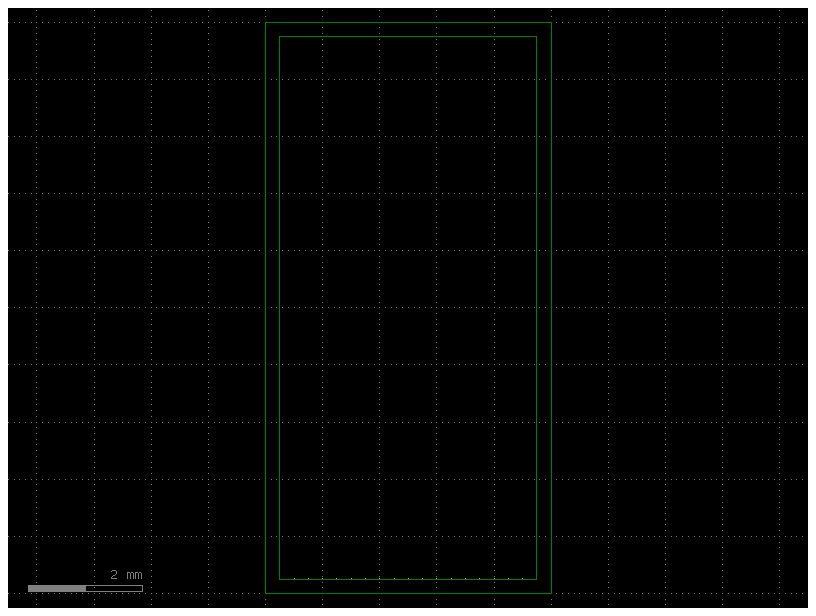

In [133]:
@gf.cell
def host_component_layout() -> gf.Component:
    """
    Componente anfitrión (host) de nivel superior que instancia 
    el Die completo de 5x10 mm con sus puertos de I/O accesibles.
    """
    c = gf.Component("Host_Layout")
    
    # Instanciamos la celda del die completo que diseñamos en el paso anterior
    die_ref = c.add_ref(die_5x10mm_with_ios())
    
    # Heredamos los puertos del die hacia el componente superior para que sigan accesibles
    c.add_ports(die_ref.ports)
    
    return c


if __name__ == "__main__":
    # Generación y visualización del lienzo host final de la práctica
    layout_final = host_component_layout()
    layout_final.plot()
    layout_final.show()

Ejercicio 4c) 2

2026-06-12 14:01:51.682 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


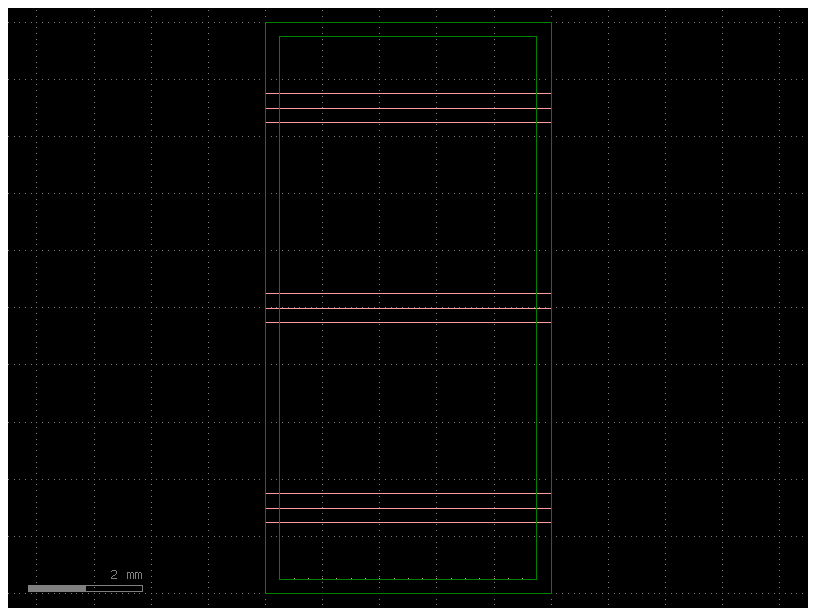

In [134]:
gf.clear_cache()

@gf.cell
def host_component_layout(
    dieW: float = 5000.0, 
    dieL: float = 10000.0, 
    width_wg: float = 1.2
) -> gf.Component:
    """
    Componente anfitrión definitivo. Instancia el Die base e integra 
    los 3 conjuntos de 3 guías de onda rectas de izquierda a derecha.
    """
    c = gf.Component("Host_Layout")
    
    # 1. Instanciamos el marco de nuestro Die de 5x10 mm con sus I/Os
    die_ref = c.add_ref(die_5x10mm_with_ios(dieW=dieW, dieL=dieL))
    c.add_ports(die_ref.ports)
    
    # 2. Configuración técnica para las guías rectas de prueba
    capa_base = gf.components.straight().ports["o1"].layer
    seccion = gf.cross_section.cross_section(width=width_wg, layer=capa_base)
    
    # Cada guía mide exactamente el ancho total del chip (5000 um) para cruzarlo entero
    guia_recta_larga = gf.components.straight(length=dieW, cross_section=seccion)
    
    # 3. Definición de las alturas (Y) para los 3 conjuntos (3 guías por conjunto)
    alturas_bottom = [1250.0, 1500.0, 1750.0]
    alturas_middle = [4750.0, 5000.0, 5250.0]
    alturas_top    = [8250.0, 8500.0, 8750.0]
    
    # Unificamos todas las posiciones en una sola lista para iterar limpiamente
    todas_las_alturas = alturas_bottom + alturas_middle + alturas_top
    
    # 4. Inyección de las 9 guías en el Layout
    for idx, y_pos in enumerate(todas_las_alturas):
        guia_ref = c.add_ref(guia_recta_larga)
        # Forzamos a que la guía empiece en X=0 y se coloque en su altura Y correspondiente
        guia_ref.move((0.0, y_pos))
        
        # Añadimos puertos en los extremos de estas guías por si hiciera falta medirlas
        c.add_port(name=f"straight_test_in_{idx}", port=guia_ref.ports["o1"])
        c.add_port(name=f"straight_test_out_{idx}", port=guia_ref.ports["o2"])
        
    return c


if __name__ == "__main__":
    # Compilación y refresco del lienzo general
    layout_final = host_component_layout()
    layout_final.plot()
    layout_final.show()

Ejercicio 4c) 3

2026-06-12 14:01:52.261 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


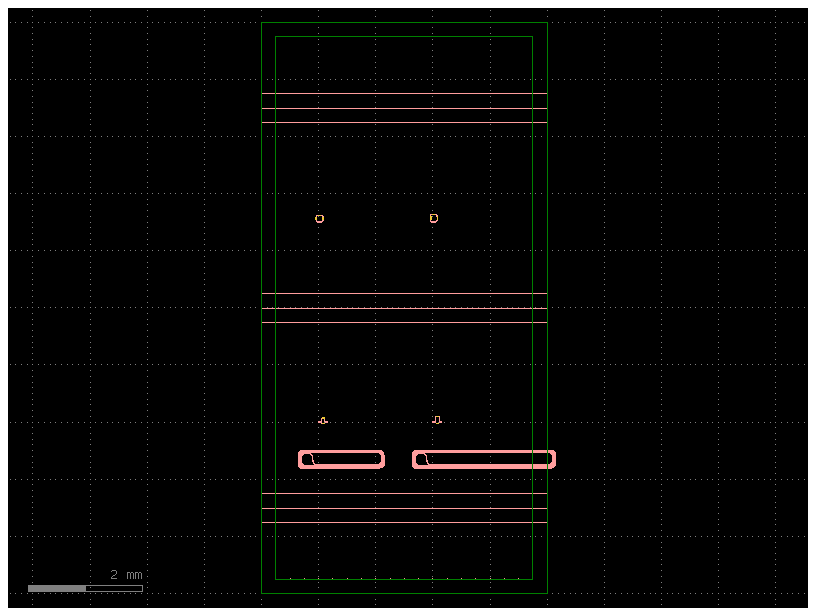

In [135]:
gf.clear_cache()

@gf.cell
def host_component_layout(
    dieW: float = 5000.0, 
    dieL: float = 10000.0, 
    width_wg: float = 1.2
) -> gf.Component:
    """
    Componente anfitrión definitivo. Instancia el Die base, las 9 guías 
    rectas y añade 2 variantes de longitud para cada componente óptico básico.
    """
    c = gf.Component("Host_Layout")
    
    # 1. Instanciamos el marco de nuestro Die de 5x10 mm con sus I/Os
    die_ref = c.add_ref(die_5x10mm_with_ios(dieW=dieW, dieL=dieL))
    c.add_ports(die_ref.ports)
    
    # 2. Configuración y trazado de las 9 guías rectas de prueba (del punto anterior)
    capa_base = gf.components.straight().ports["o1"].layer
    seccion = gf.cross_section.cross_section(width=width_wg, layer=capa_base)
    guia_recta_larga = gf.components.straight(length=dieW, cross_section=seccion)
    
    alturas_rectas = [1250.0, 1500.0, 1750.0, 4750.0, 5000.0, 5250.0, 8250.0, 8500.0, 8750.0]
    for idx, y_pos in enumerate(alturas_rectas):
        guia_ref = c.add_ref(guia_recta_larga)
        guia_ref.move((0.0, y_pos))
        c.add_port(name=f"straight_test_in_{idx}", port=guia_ref.ports["o1"])
        c.add_port(name=f"straight_test_out_{idx}", port=guia_ref.ports["o2"])
        
    # =======================================================================
    # COLOCACIÓN DE PAREJAS DE COMPONENTES (Variantes de longitud)
    # =======================================================================
    
    # --- PAREJA 1: Interferómetros Mach-Zehnder (MZIs con calentadores) ---
    mzi_v1 = c.add_ref(mzi_with_horizontal_tuners(delta_l=100.0, L_h=40.0))
    mzi_v1.move((1000.0, 3000.0))  # Variante 1 colocada a la izquierda
    
    mzi_v2 = c.add_ref(mzi_with_horizontal_tuners(delta_l=160.0, L_h=40.0))
    mzi_v2.move((3000.0, 3000.0))  # Variante 2 colocada a la derecha

    # --- PAREJA 2: Resonadores de Anillo (All-pass rings con calentadores) ---
    ring_v1 = c.add_ref(ring_allpass_with_tuners(radius=37.69, extra_length=40.0))
    ring_v1.move((1000.0, 6500.0)) # Variante 1 colocada a la izquierda
    
    ring_v2 = c.add_ref(ring_allpass_with_tuners(radius=37.69, extra_length=90.0))
    ring_v2.move((3000.0, 6500.0)) # Variante 2 colocada a la derecha

    # --- PAREJA 3: Espirales fotónicas ---
    spiral_v1 = c.add_ref(spiral_with_length_param(length=1000.0, spacing=10.0))
    spiral_v1.move((1000.0, 2250.0)) # Variante 1 colocada a la izquierda
    
    spiral_v2 = c.add_ref(spiral_with_length_param(length=2000.0, spacing=10.0))
    spiral_v2.move((3000.0, 2250.0)) # Variante 2 colocada a la derecha

    # Exponemos algunos puertos de los componentes hacia el Host para el ruteado final
    c.add_port(name="mzi1_in", port=mzi_v1.ports["in_top"])
    c.add_port(name="mzi1_out", port=mzi_v1.ports["out_top"])
    c.add_port(name="mzi2_in", port=mzi_v2.ports["in_top"])
    c.add_port(name="mzi2_out", port=mzi_v2.ports["out_top"])
    
    c.add_port(name="ring1_in", port=ring_v1.ports["in0"])
    c.add_port("ring1_out", port=ring_v1.ports["out0"])
    c.add_port(name="ring2_in", port=ring_v2.ports["in0"])
    c.add_port("ring2_out", port=ring_v2.ports["out0"])
    
    return c


if __name__ == "__main__":
    # Compilación y actualización del mapa global del chip
    layout_final = host_component_layout()
    layout_final.plot()
    layout_final.show()

Ejercicio 4c) 4

2026-06-12 15:58:16.156 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


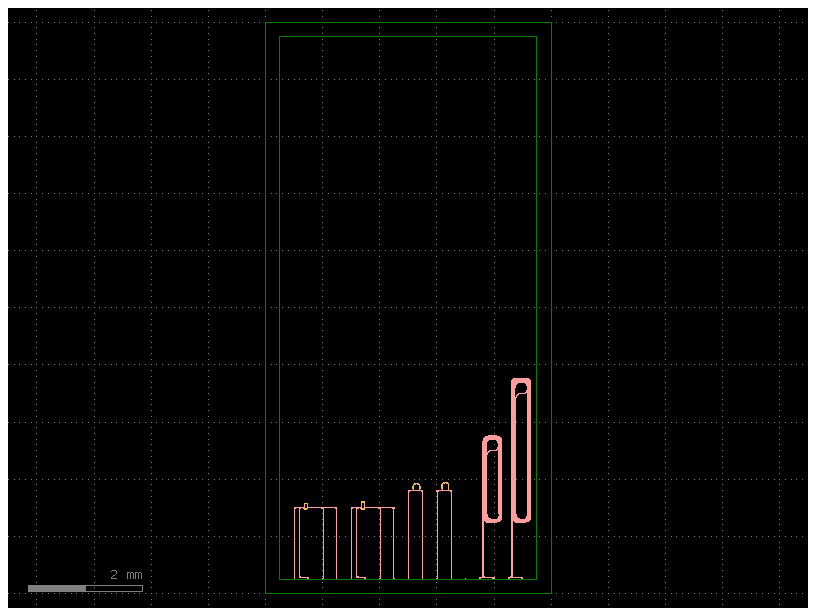

In [157]:
gf.clear_cache()

@gf.cell
def host_component_layout(
    dieW: float = 5000.0, 
    dieL: float = 10000.0, 
    width_wg: float = 1.2
) -> gf.Component:
    """
    Componente raíz definitivo y corregido. Extrae los puertos de las espirales
    DESPUÉS de realizar la alineación vertical para asegurar un ruteado perfecto.
    """
    c = gf.Component("Host_Layout")
    
    # 1. Instanciamos el marco del Die de 5x10 mm con sus I/Os
    die_ref = c.add_ref(die_5x10mm_with_ios(dieW=dieW, dieL=dieL))
    c.add_ports(die_ref.ports)
    
    # Configuración de la sección con radio de curvatura para pérdidas mínimas
    capa_base = gf.components.straight().ports["o1"].layer
    seccion = gf.cross_section.cross_section(width=width_wg, layer=capa_base, radius=20.0)
    
    # =======================================================================
    # 2. INSTANCIACIÓN Y ALINEACIÓN DE COMPONENTES
    # =======================================================================
    # MZIs 
    mzi_v1 = c.add_ref(mzi_with_horizontal_tuners(delta_l=100.0, L_h=40.0))
    mzi_v1.move((625.0, 1500.0))  
    
    mzi_v2 = c.add_ref(mzi_with_horizontal_tuners(delta_l=160.0, L_h=40.0))
    mzi_v2.move((1625.0, 1500.0)) 

    # Anillos
    ring_v1 = c.add_ref(ring_allpass_with_tuners(radius=37.69, extra_length=40.0))
    ring_v1.move((2625.0, 1800.0)) 
    
    ring_v2 = c.add_ref(ring_allpass_with_tuners(radius=37.69, extra_length=90.0))
    ring_v2.move((3125.0, 1800.0)) 

    # ESPIRALES: Rotadas a 270° (puertos hacia abajo)
    spiral_v1 = c.add_ref(spiral_with_length_param(length=1000.0, spacing=10.0))
    spiral_v1.rotate(270)
    spiral_v1.move((3875.0, 2400.0)) 
    
    spiral_v2 = c.add_ref(spiral_with_length_param(length=2000.0, spacing=10.0))
    spiral_v2.rotate(270)
    spiral_v2.move((4375.0, 2400.0)) 
    
    # --- CALCULO DE ALINEACIÓN VERTICAL ---
    try:
        y_puerto_espiral1 = list(spiral_v1.ports)[0].center[1]
        y_puerto_espiral2 = list(spiral_v2.ports)[0].center[1]
    except AttributeError:
        y_puerto_espiral1 = list(spiral_v1.ports)[0].y
        y_puerto_espiral2 = list(spiral_v2.ports)[0].y
            
    desfase_y = y_puerto_espiral1 - y_puerto_espiral2
    spiral_v2.movey(desfase_y)

    # CRÍTICO: Extraemos las listas de puertos AQUÍ, después de los movimientos
    p_sp1 = list(spiral_v1.ports)
    p_sp2 = list(spiral_v2.ports)

    # =======================================================================
    # 3. ENRUTADO DE ALTA PRECISIÓN HACIA LAS I/Os INFERIORES
    # =======================================================================
    def conectar_puertos(p1, p2):
        try:
            gf.routing.route_single(component=c, port1=p1, port2=p2, cross_section=seccion)
        except Exception:
            pass

    # Conexiones MZI 1
    conectar_puertos(die_ref.ports["bot_io_1"], mzi_v1.ports["in_top"]) 
    conectar_puertos(die_ref.ports["bot_io_2"], mzi_v1.ports["in_bot"]) 
    conectar_puertos(die_ref.ports["bot_io_3"], mzi_v1.ports["out_top"]) 
    conectar_puertos(die_ref.ports["bot_io_4"], mzi_v1.ports["out_bot"]) 

    # Conexiones MZI 2
    conectar_puertos(die_ref.ports["bot_io_5"], mzi_v2.ports["in_top"])
    conectar_puertos(die_ref.ports["bot_io_6"], mzi_v2.ports["in_bot"])
    conectar_puertos(die_ref.ports["bot_io_7"], mzi_v2.ports["out_top"])
    conectar_puertos(die_ref.ports["bot_io_8"], mzi_v2.ports["out_bot"])

    # Conexiones Anillos
    conectar_puertos(die_ref.ports["bot_io_9"], ring_v1.ports["in0"])
    conectar_puertos(die_ref.ports["bot_io_10"], ring_v1.ports["out0"])
    conectar_puertos(die_ref.ports["bot_io_11"], ring_v2.ports["in0"])
    conectar_puertos(die_ref.ports["bot_io_12"], ring_v2.ports["out0"])

    # Conexiones Espirales Niveladas (Ahora con coordenadas reales y actualizadas)
    if len(p_sp1) >= 2:
        conectar_puertos(die_ref.ports["bot_io_14"], p_sp1[0])
        conectar_puertos(die_ref.ports["bot_io_15"], p_sp1[1])
        
    if len(p_sp2) >= 2:
        conectar_puertos(die_ref.ports["bot_io_16"], p_sp2[0])
        conectar_puertos(die_ref.ports["bot_io_17"], p_sp2[1])

    return c


if __name__ == "__main__":
    # Renderizamos el circuito integrado final con ruteado corregido
    layout_final = host_component_layout()
    layout_final.plot()
    layout_final.show()